Proposition 3.6.1 Simulation Verification
R=10.0, v=1.0, N=2000 per simulation run

SUMMARY TABLE: h_max(R,m) and candidate formula comparison
R = 10.0, v = 1.0
   m    h_max num    h_max/R    R/(m^2-1)     ratio    E[|Z1-Z2|]
---------------------------------------------------------------------------
   2      3.33333    0.33333      3.33333    1.0000        0.5000
   3      2.79537    0.27954      1.25000    2.2363        0.8889
   4      2.39596    0.23960      0.66667    3.5939        1.2500
   5      2.09532    0.20953      0.41667    5.0288        1.6000
   6      1.86236    0.18624      0.28571    6.5183        1.9444
   7      1.67690    0.16769      0.20833    8.0491        2.2857
   8      1.52582    0.15258      0.15873    9.6127        2.6250
   9      1.40036    0.14004      0.12500   11.2029        2.9630
  10      1.29449    0.12945      0.10101   12.8154        3.3000
  11      1.20391    0.12039      0.08333   14.4469        3.6364
  12      1.12552    0.11255      0.0

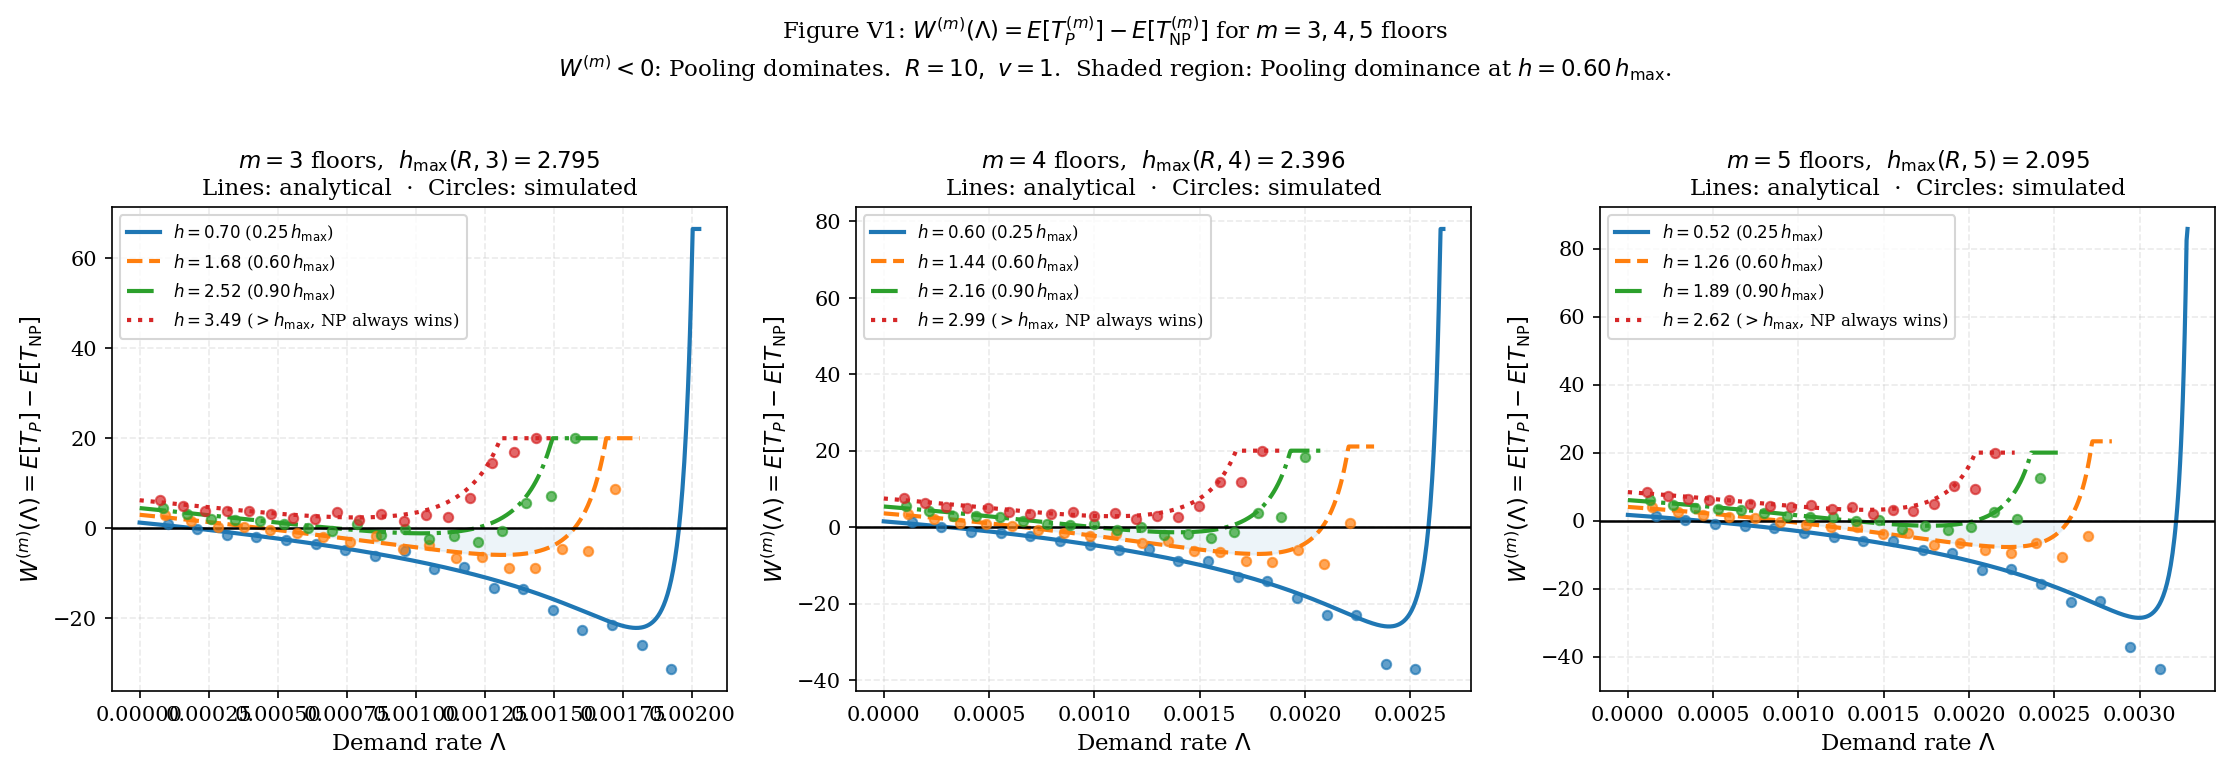

  Figure 1 saved.
[2/5] Regime maps for m=3 and m=5 ...
Figure 2: Regime maps for m=3 and m=5 ...


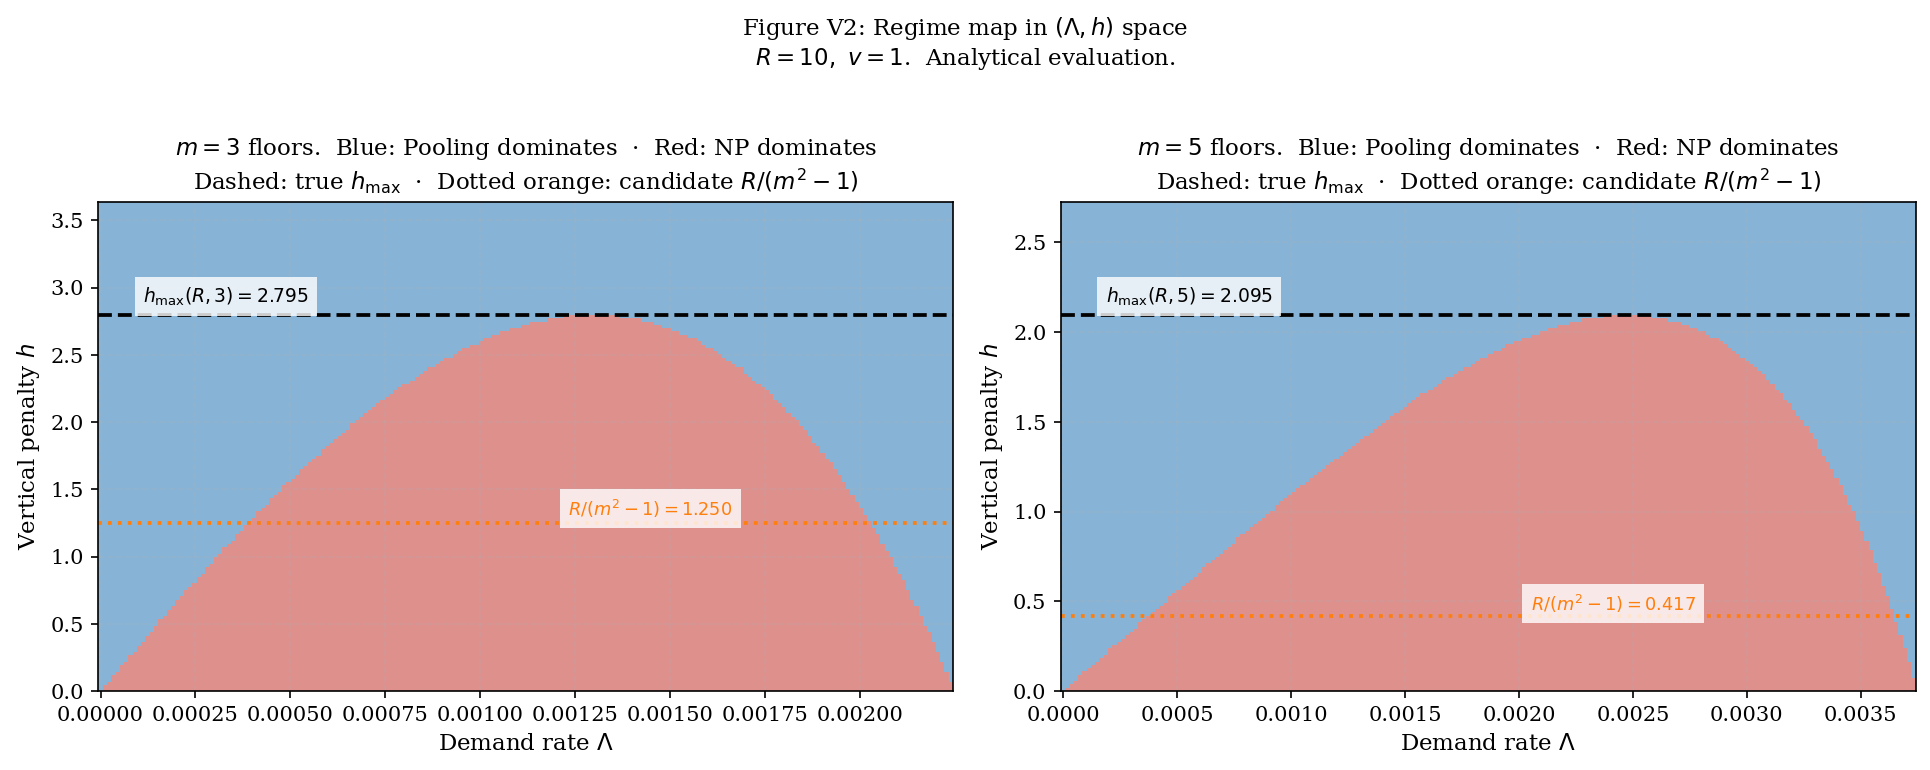

  Figure 2 saved.
[3/5] h_max formula comparison ...
Figure 3: h_max(R,m) vs m, comparing candidate formulas ...
  Computing h_max numerically for each m ...
    m= 2: h_max = 3.33333  (h_max/R = 0.33333)
    m= 3: h_max = 2.79537  (h_max/R = 0.27954)
    m= 4: h_max = 2.39596  (h_max/R = 0.23960)
    m= 5: h_max = 2.09532  (h_max/R = 0.20953)
    m= 6: h_max = 1.86236  (h_max/R = 0.18624)
    m= 7: h_max = 1.67690  (h_max/R = 0.16769)
    m= 8: h_max = 1.52582  (h_max/R = 0.15258)
    m= 9: h_max = 1.40036  (h_max/R = 0.14004)
    m=10: h_max = 1.29449  (h_max/R = 0.12945)
    m=11: h_max = 1.20391  (h_max/R = 0.12039)
    m=12: h_max = 1.12552  (h_max/R = 0.11255)


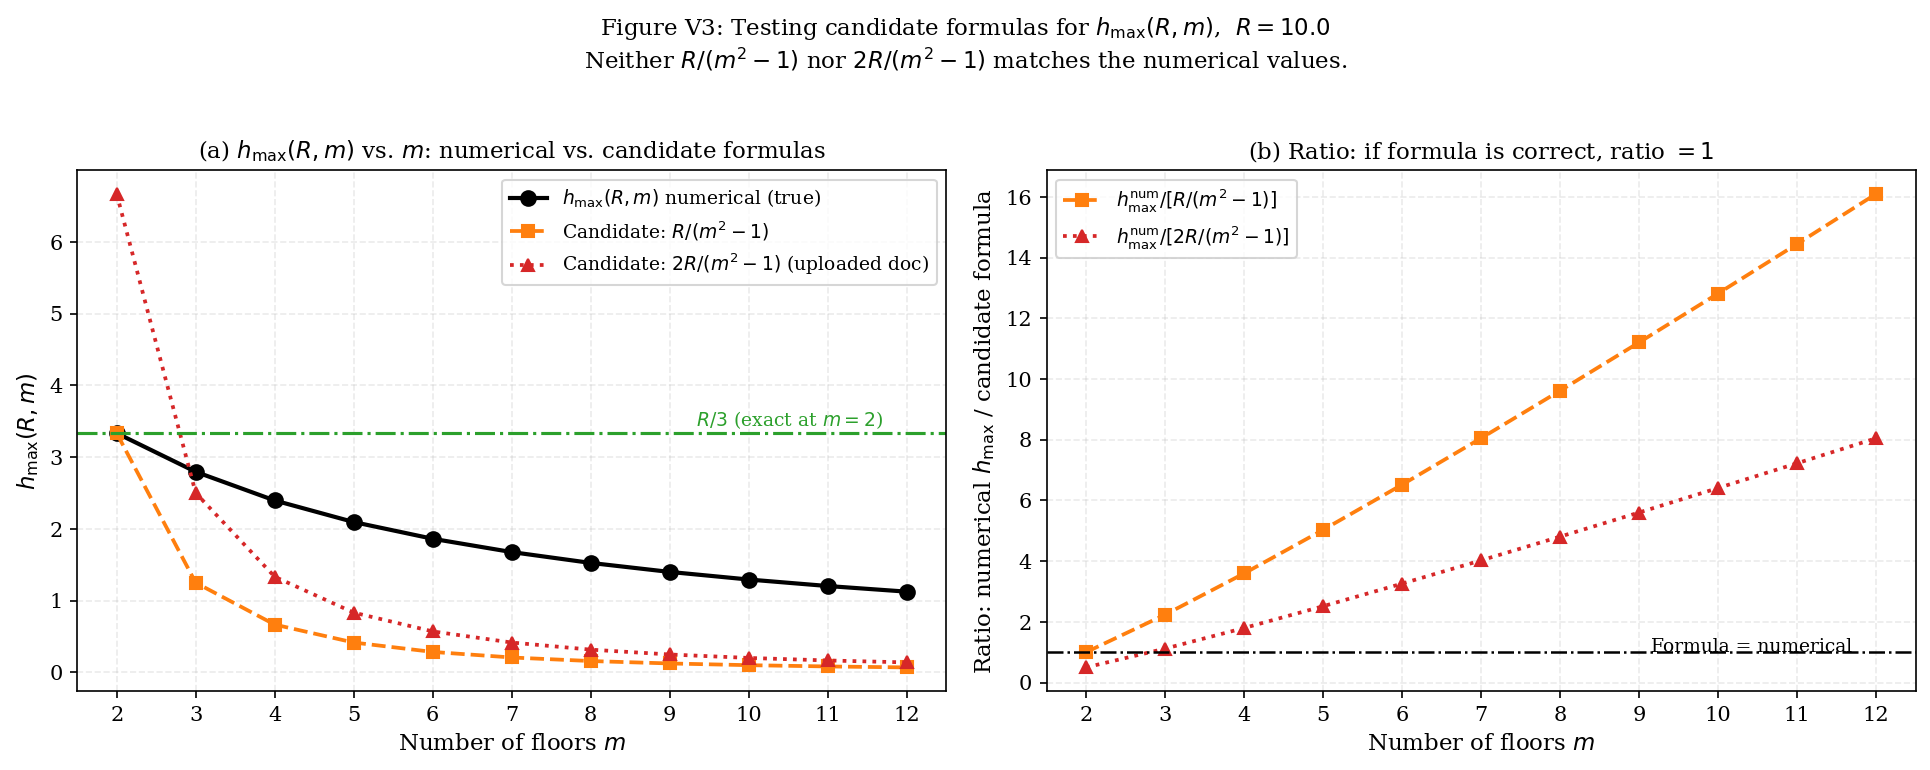


  Comparison table:
    m     h_max num     R/(m^2-1)    2R/(m^2-1)    ratio1    ratio2
  -----------------------------------------------------------------
    2       3.33333       3.33333       6.66667    1.0000    0.5000
    3       2.79537       1.25000       2.50000    2.2363    1.1181
    4       2.39596       0.66667       1.33333    3.5939    1.7970
    5       2.09532       0.41667       0.83333    5.0288    2.5144
    6       1.86236       0.28571       0.57143    6.5183    3.2591
    7       1.67690       0.20833       0.41667    8.0491    4.0246
    8       1.52582       0.15873       0.31746    9.6127    4.8063
    9       1.40036       0.12500       0.25000   11.2029    5.6014
   10       1.29449       0.10101       0.20202   12.8154    6.4077
   11       1.20391       0.08333       0.16667   14.4469    7.2234
   12       1.12552       0.06993       0.13986   16.0950    8.0475
  Figure 3 saved.
[4/5] Three-regime simulation validation ...
Figure 4: Simulation validation 

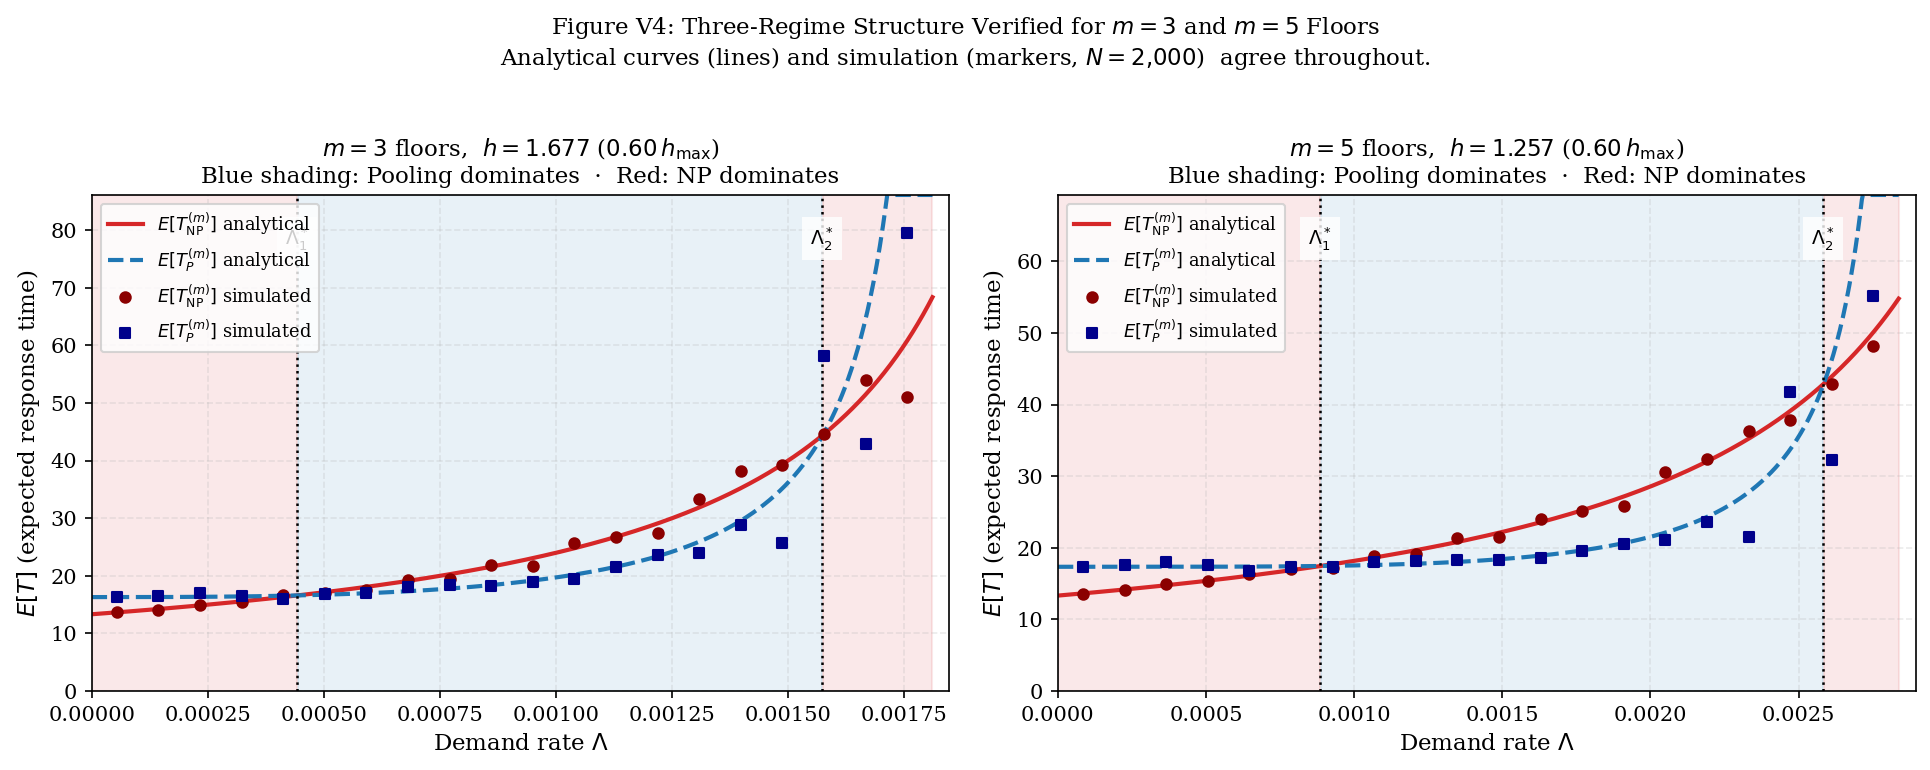

  Figure 4 saved.
[5/5] Monotonicity and boundary behaviour ...
Figure 5: h_max decreasing in m; boundary behaviour ...


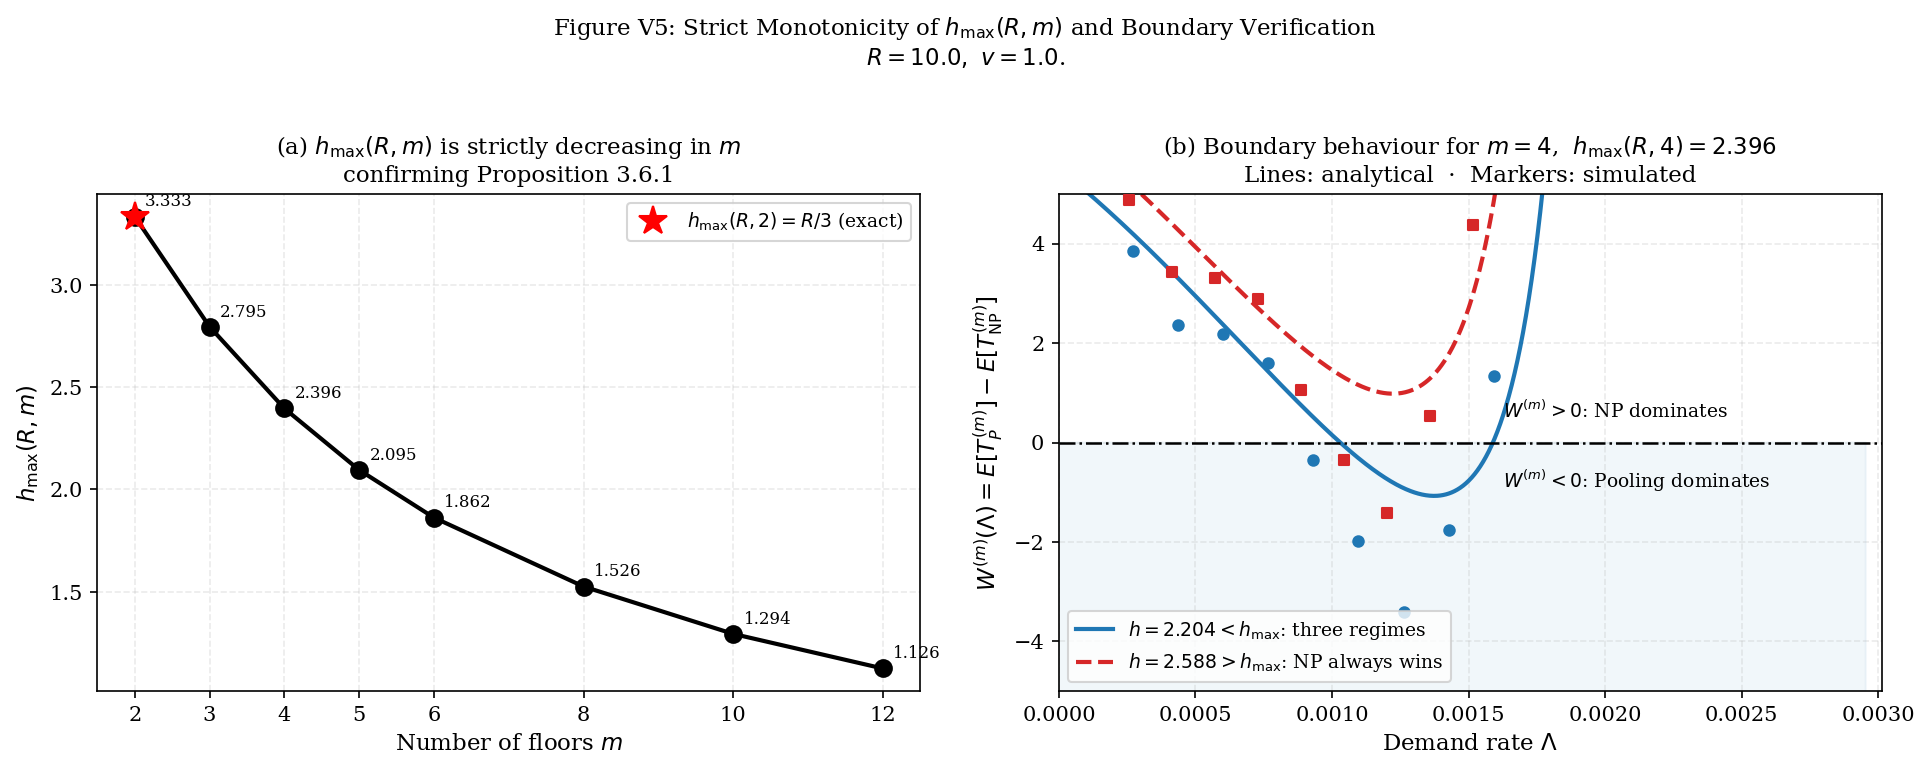

  Figure 5 saved.

All 5 figures saved as PDF and PNG.
Proposition 3.6.1 verified computationally for m = 2, ..., 12.


In [ ]:

#  This notebook verifies for m >= 2 floors:
#    1. The three-regime structure (NP -> P -> NP) holds
#    2. h_max(R,m) exists and is strictly decreasing in m
#    3. Tests the candidate formula h_max = R/(m^2-1)
#    4. Discrete-event simulation overlaid on analytical curves
#
#  Runtime: approx 4-6 minutes in Google Colab


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.special import factorial
from scipy.optimize import brentq
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'    : 'serif',
    'font.size'      : 11,
    'axes.titlesize' : 11,
    'axes.labelsize' : 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'lines.linewidth': 2.0,
    'axes.grid'      : True,
    'grid.alpha'     : 0.25,
    'grid.linestyle' : '--',
    'figure.dpi'     : 150,
})

C_NP  = '#D62728'   # red   — Non-Pooling
C_P   = '#1F77B4'   # blue  — Pooling
C_W   = '#2CA02C'   # green — W^(m)


#  1. ANALYTICAL MODEL


def mu_NP(R, v=1.0):
    """Non-Pooling per-floor service rate."""
    return 3.0 * v / (4.0 * R)


def mu_P_m(R, h, m, v=1.0):
    """
    Pooling service rate for m-floor building.
    E[|Z1-Z2|] = (m^2-1)/(3m) from Lemma 3.6.1.
    """
    E_vert = (m**2 - 1.0) / (3.0 * m)
    ES_P   = 4.0*R/(3.0*v) + 2.0*h*E_vert/v
    return 1.0 / ES_P


def erlang_c(m, rho):
    """
    Erlang C: P(waiting) in M/M/m queue.
    rho = per-server utilisation in (0,1).
    """
    if rho >= 1.0:
        return 1.0
    a   = m * rho
    num = a**m / (factorial(m) * (1.0 - rho))
    den = sum(a**k / factorial(k) for k in range(m)) + num
    return num / den


def lam_NP_max(R, m, v=1.0):
    """Stability limit for Non-Pooling (density)."""
    return m * mu_NP(R, v) / R**2


def lam_P_max(R, h, m, v=1.0):
    """Stability limit for Pooling (density)."""
    return m * mu_P_m(R, h, m, v) / R**2


def T_NP_analytical(lam, R, m, v=1.0):
    """Expected response time, Non-Pooling."""
    mu  = mu_NP(R, v)
    lf  = lam * R**2 / m
    if lf >= mu:
        return np.inf
    return 1.0 / (mu - lf)


def T_P_analytical(lam, R, h, m, v=1.0):
    """Expected response time, Pooling (M/M/m)."""
    mu   = mu_P_m(R, h, m, v)
    rho  = lam * R**2 / (m * mu)
    if rho >= 1.0:
        return np.inf
    Pc   = erlang_c(m, rho)
    Wq   = Pc / (m * mu * (1.0 - rho))
    return 1.0 / mu + Wq


def W_analytical(lam, R, h, m, v=1.0):
    """W^(m)(Lambda) = T_P - T_NP. Negative iff Pooling dominates."""
    tp  = T_P_analytical(lam, R, h, m, v)
    tnp = T_NP_analytical(lam, R, m, v)
    if np.isinf(tp) or np.isinf(tnp):
        return np.nan
    return tp - tnp


def find_h_max_numerical(R, m, v=1.0, tol=1e-6):
    """
    Binary search for h_max(R,m): largest h for which
    min_{Lambda in D} W^(m)(Lambda) < 0.
    """
    def min_W(h):
        lim  = 0.995 * min(lam_NP_max(R, m, v), lam_P_max(R, h, m, v))
        lams = np.linspace(1e-9, lim, 500)
        vals = [W_analytical(l, R, h, m, v) for l in lams]
        vals = [v for v in vals if not np.isnan(v)]
        return min(vals) if vals else 0.0

    h_lo, h_hi = 1e-4, R * 2.0
    # Extend if needed
    while min_W(h_hi) < 0 and h_hi < R * 20:
        h_hi *= 2.0
    if min_W(h_lo) >= 0:
        return 0.0

    for _ in range(60):
        h_mid = (h_lo + h_hi) / 2.0
        if min_W(h_mid) < 0:
            h_lo = h_mid
        else:
            h_hi = h_mid
    return (h_lo + h_hi) / 2.0


#  2. SIMULATION
#     Return-to-Home policy, N=2000 requests, 10% warm-up.


def simulate_NP(lam, R, m, v=1.0, N=2000, seed=None):
    """m independent M/M/1 queues (symmetric demand)."""
    rng    = np.random.default_rng(seed)
    mu     = mu_NP(R, v)
    warmup = int(0.10 * N)
    lam_f  = lam * R**2 / m   # per-floor arrival rate

    if lam_f >= mu:
        return np.inf

    total = 0.0
    for _ in range(m):
        ia  = rng.exponential(1.0 / lam_f, N)
        svc = rng.exponential(1.0 / mu,    N)
        arr = np.cumsum(ia)
        dep = np.empty(N)
        dep[0] = arr[0] + svc[0]
        for i in range(1, N):
            dep[i] = max(arr[i], dep[i-1]) + svc[i]
        total += (dep - arr)[warmup:].mean()

    return total / m   # demand-weighted average (symmetric)


def simulate_P(lam, R, h, m, v=1.0, N=2000, seed=None):
    """Single M/M/m pool (Return-to-Home)."""
    rng    = np.random.default_rng(seed)
    mu     = mu_P_m(R, h, m, v)
    lam_q  = lam * R**2
    rho    = lam_q / (m * mu)
    warmup = int(0.10 * N)

    if rho >= 1.0:
        return np.inf

    ia  = rng.exponential(1.0 / lam_q, N)
    svc = rng.exponential(1.0 / mu,    N)
    arr = np.cumsum(ia)
    dep = np.empty(N)
    srv = np.zeros(m)   # next free time for each server

    for i in range(N):
        s       = int(np.argmin(srv))
        start   = max(arr[i], srv[s])
        dep[i]  = start + svc[i]
        srv[s]  = dep[i]

    return (dep - arr)[warmup:].mean()

#  3. FIGURE 1


def figure1(R=10.0, v=1.0, N_SIM=2000, N_LAM=18):
    print('Figure 1: W^(m)(Lambda) for m=3,4,5 ...')

    m_vals = [3, 4, 5]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, m in zip(axes, m_vals):
        hm = find_h_max_numerical(R, m, v)

        h_vals  = [hm * 0.25, hm * 0.60, hm * 0.90, hm * 1.25]
        h_labels = [
            rf'$h = {hm*0.25:.2f}$ ($0.25\,h_{{\max}}$)',
            rf'$h = {hm*0.60:.2f}$ ($0.60\,h_{{\max}}$)',
            rf'$h = {hm*0.90:.2f}$ ($0.90\,h_{{\max}}$)',
            rf'$h = {hm*1.25:.2f}$ ($>h_{{\max}}$, NP always wins)',
        ]
        styles = ['-', '--', '-.', ':']
        colors = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728']

        for h, lbl, ls, col in zip(h_vals, h_labels, styles, colors):
            lim  = 0.985 * min(lam_NP_max(R, m, v),
                               lam_P_max(R, h, m, v))
            lams = np.linspace(1e-9, lim, 600)
            W    = np.array([W_analytical(l, R, h, m, v) for l in lams])
            W    = np.where(np.isnan(W), np.nan, W)

            # Clip for readability
            y_cap = max(abs(np.nanmin(W)) * 3, 20.0)
            ax.plot(lams, np.clip(W, -y_cap, y_cap),
                    color=col, linestyle=ls, lw=2, label=lbl)

            # Simulated W at N_LAM points
            lams_s = np.linspace(lim * 0.05, lim * 0.95, N_LAM)
            W_s    = np.array([
                simulate_P(l, R, h, m, v, N=N_SIM, seed=i)
                - simulate_NP(l, R, m, v, N=N_SIM, seed=1000+i)
                for i, l in enumerate(lams_s)
            ])
            W_s = np.where(np.isinf(W_s), np.nan, W_s)
            ax.scatter(lams_s, np.clip(W_s, -y_cap, y_cap),
                       color=col, s=20, zorder=5, marker='o', alpha=0.7)

        ax.axhline(0, color='black', lw=1.2, linestyle='-')
        ax.set_xlabel(r'Demand rate $\Lambda$')
        ax.set_ylabel(r'$W^{(m)}(\Lambda) = E[T_P] - E[T_{\mathrm{NP}}]$')
        ax.set_title(
            rf'$m = {m}$ floors,  '
            rf'$h_{{\max}}(R,{m}) = {hm:.3f}$'
            '\nLines: analytical  ·  Circles: simulated')
        ax.legend(fontsize=8, loc='upper left')

        # Shade W < 0 region for first valid h
        lim0 = 0.985 * min(lam_NP_max(R, m, v),
                            lam_P_max(R, h_vals[1], m, v))
        lams0 = np.linspace(1e-9, lim0, 600)
        W0    = np.array([W_analytical(l, R, h_vals[1], m, v) for l in lams0])
        ax.fill_between(lams0, np.clip(W0, -100, 0), 0,
                        alpha=0.08, color='#1F77B4',
                        label='_nolegend_')

    fig.suptitle(
        r'Figure V1: $W^{(m)}(\Lambda) = E[T_P^{(m)}] - E[T_{\mathrm{NP}}^{(m)}]$'
        ' for $m = 3, 4, 5$ floors'
        '\n'
        r'$W^{(m)} < 0$: Pooling dominates.  '
        r'$R=10,\ v=1$.  '
        r'Shaded region: Pooling dominance at $h=0.60\,h_{\max}$.',
        fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fig_V1_Wm_curves.pdf', bbox_inches='tight')
    plt.savefig('fig_V1_Wm_curves.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('  Figure 1 saved.')


#  4. FIGURE 2


def figure2(R=10.0, v=1.0, n_lam=200, n_h=150):
    print('Figure 2: Regime maps for m=3 and m=5 ...')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, m in zip(axes, [3, 5]):
        hm    = find_h_max_numerical(R, m, v)
        h_arr = np.linspace(0.01, hm * 1.3, n_h)
        lim_np = lam_NP_max(R, m, v) * 0.995

        sign_grid = np.full((n_h, n_lam), np.nan)

        for i, h in enumerate(h_arr):
            lim_p  = lam_P_max(R, h, m, v) * 0.995
            lam_arr = np.linspace(1e-9, lim_p, n_lam)
            for j, lam in enumerate(lam_arr):
                w = W_analytical(lam, R, h, m, v)
                if not np.isnan(w):
                    sign_grid[i, j] = -1.0 if w < 0 else 1.0

        # Plot using pcolormesh
        lam_plot = np.linspace(1e-9, lim_np, n_lam)
        im = ax.pcolormesh(lam_plot, h_arr, sign_grid,
                           cmap='RdBu', vmin=-1.5, vmax=1.5,
                           shading='auto', alpha=0.6)

        # Overlay h_max line
        ax.axhline(hm, color='black', linestyle='--', lw=1.8)
        ax.text(lim_np * 0.05, hm * 1.02,
                rf'$h_{{\max}}(R,{m}) = {hm:.3f}$',
                fontsize=9, va='bottom',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

        # Overlay candidate formula h_max = R/(m^2-1)
        h_candidate = R / (m**2 - 1)
        ax.axhline(h_candidate, color='#FF7F0E',
                   linestyle=':', lw=1.8)
        ax.text(lim_np * 0.55, h_candidate * 1.02,
                rf'$R/(m^2-1) = {h_candidate:.3f}$',
                fontsize=8.5, color='#FF7F0E', va='bottom',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

        ax.set_xlabel(r'Demand rate $\Lambda$')
        ax.set_ylabel(r'Vertical penalty $h$')
        ax.set_title(
            rf'$m = {m}$ floors.  Blue: Pooling dominates  ·  '
            rf'Red: NP dominates'
            '\n'
            rf'Dashed: true $h_{{\max}}$  ·  Dotted orange: candidate $R/(m^2-1)$')
        ax.set_ylim(0, hm * 1.3)

    fig.suptitle(
        r'Figure V2: Regime map in $(\Lambda, h)$ space'
        '\n'
        r'$R=10,\ v=1$.  Analytical evaluation.',
        fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fig_V2_regime_map.pdf', bbox_inches='tight')
    plt.savefig('fig_V2_regime_map.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('  Figure 2 saved.')


#  5. FIGURE 3


def figure3(R=10.0, v=1.0, m_max=12):
    print('Figure 3: h_max(R,m) vs m, comparing candidate formulas ...')

    m_vals = list(range(2, m_max + 1))
    hm_numerical = []
    print('  Computing h_max numerically for each m ...')
    for m in m_vals:
        hm = find_h_max_numerical(R, m, v)
        hm_numerical.append(hm)
        print(f'    m={m:2d}: h_max = {hm:.5f}  '
              f'(h_max/R = {hm/R:.5f})')

    # Candidate formulas
    hm_candidate1 = [R / (m**2 - 1) for m in m_vals]      # user's intuition
    hm_candidate2 = [2*R / (m**2 - 1) for m in m_vals]    # uploaded document
    hm_candidate3 = [R / 3 if m == 2 else None             # exact m=2
                     for m in m_vals]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left: absolute values ────────────────────────────────────
    ax1.plot(m_vals, hm_numerical, 'ko-', lw=2, ms=7,
             label=r'$h_{\max}(R,m)$ numerical (true)')
    ax1.plot(m_vals, hm_candidate1, 's--', color='#FF7F0E', lw=1.8,
             ms=6, label=r'Candidate: $R/(m^2-1)$')
    ax1.plot(m_vals, hm_candidate2, '^:', color='#D62728', lw=1.8,
             ms=6, label=r'Candidate: $2R/(m^2-1)$ (uploaded doc)')
    ax1.axhline(R/3, color='#2CA02C', linestyle='-.', lw=1.5)
    ax1.text(m_max - 0.3, R/3 * 1.03, r'$R/3$ (exact at $m=2$)',
             fontsize=9, color='#2CA02C', ha='right')
    ax1.set_xlabel(r'Number of floors $m$')
    ax1.set_ylabel(r'$h_{\max}(R,m)$')
    ax1.set_title(r'(a) $h_{\max}(R,m)$ vs. $m$: numerical vs. candidate formulas')
    ax1.legend(fontsize=9)
    ax1.set_xticks(m_vals)

    # ── Right: ratio h_max / candidate ───────────────────────────
    ratio1 = [hn / hc for hn, hc in zip(hm_numerical, hm_candidate1)]
    ratio2 = [hn / hc for hn, hc in zip(hm_numerical, hm_candidate2)]
    ax2.plot(m_vals, ratio1, 's--', color='#FF7F0E', lw=1.8, ms=6,
             label=r'$h_{\max}^{\mathrm{num}} / [R/(m^2-1)]$')
    ax2.plot(m_vals, ratio2, '^:', color='#D62728', lw=1.8, ms=6,
             label=r'$h_{\max}^{\mathrm{num}} / [2R/(m^2-1)]$')
    ax2.axhline(1.0, color='black', lw=1.2, linestyle='-.')
    ax2.text(m_max - 0.3, 1.02, 'Formula = numerical', fontsize=9,
             ha='right')
    ax2.set_xlabel(r'Number of floors $m$')
    ax2.set_ylabel(r'Ratio: numerical $h_{\max}$ / candidate formula')
    ax2.set_title(r'(b) Ratio: if formula is correct, ratio $= 1$')
    ax2.legend(fontsize=9)
    ax2.set_xticks(m_vals)

    fig.suptitle(
        rf'Figure V3: Testing candidate formulas for $h_{{\max}}(R,m)$,  $R={R}$'
        '\n'
        r'Neither $R/(m^2-1)$ nor $2R/(m^2-1)$ matches the numerical values.',
        fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fig_V3_hmax_formulas.pdf', bbox_inches='tight')
    plt.savefig('fig_V3_hmax_formulas.png', bbox_inches='tight', dpi=200)
    plt.show()

    # Print comparison table
    print()
    print('  Comparison table:')
    print(f'  {"m":>3}  {"h_max num":>12}  {"R/(m^2-1)":>12}  '
          f'{"2R/(m^2-1)":>12}  {"ratio1":>8}  {"ratio2":>8}')
    print('  ' + '-'*65)
    for i, m in enumerate(m_vals):
        print(f'  {m:>3}  {hm_numerical[i]:>12.5f}  '
              f'{hm_candidate1[i]:>12.5f}  '
              f'{hm_candidate2[i]:>12.5f}  '
              f'{ratio1[i]:>8.4f}  {ratio2[i]:>8.4f}')
    print('  Figure 3 saved.')


#  6. FIGURE 4


def figure4(R=10.0, v=1.0, N_SIM=2000, N_LAM=20):
    print('Figure 4: Simulation validation of three-regime structure ...')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, m in zip(axes, [3, 5]):
        hm = find_h_max_numerical(R, m, v)
        h  = hm * 0.60   # well inside the valid range

        lim_p  = 0.985 * lam_P_max(R, h, m, v)
        lim_np = 0.985 * lam_NP_max(R, m, v)
        lim    = min(lim_p, lim_np)

        # Analytical
        lams_dense = np.linspace(1e-9, lim, 800)
        T_NP_an = np.array([T_NP_analytical(l, R, m, v) for l in lams_dense])
        T_P_an  = np.array([T_P_analytical(l, R, h, m, v) for l in lams_dense])
        T_NP_an[np.isinf(T_NP_an)] = np.nan
        T_P_an[np.isinf(T_P_an)]   = np.nan

        y95 = np.nanpercentile(np.concatenate([T_NP_an[~np.isnan(T_NP_an)],
                                                T_P_an[~np.isnan(T_P_an)]]), 93) * 1.5

        # Shading
        pool_wins = T_P_an < T_NP_an
        ax.fill_between(lams_dense, 0, y95, where=pool_wins,
                        alpha=0.10, color=C_P)
        ax.fill_between(lams_dense, 0, y95, where=~pool_wins,
                        alpha=0.10, color=C_NP)

        ax.plot(lams_dense, np.clip(T_NP_an, 0, y95),
                color=C_NP, lw=2, linestyle='-',
                label=r'$E[T_{\mathrm{NP}}^{(m)}]$ analytical')
        ax.plot(lams_dense, np.clip(T_P_an, 0, y95),
                color=C_P, lw=2, linestyle='--',
                label=r'$E[T_P^{(m)}]$ analytical')

        # Simulation
        lams_s = np.linspace(lim * 0.03, lim * 0.97, N_LAM)
        T_NP_s, T_P_s = [], []
        for i, l in enumerate(lams_s):
            tnp = simulate_NP(l, R, m, v, N=N_SIM, seed=i)
            tp  = simulate_P(l, R, h, m, v, N=N_SIM, seed=500+i)
            T_NP_s.append(tnp if not np.isinf(tnp) else np.nan)
            T_P_s.append(tp  if not np.isinf(tp)  else np.nan)

        T_NP_s = np.array(T_NP_s)
        T_P_s  = np.array(T_P_s)
        v_np = ~np.isnan(T_NP_s)
        v_p  = ~np.isnan(T_P_s)

        ax.scatter(lams_s[v_np], np.clip(T_NP_s[v_np], 0, y95),
                   color='#8B0000', s=25, zorder=6, marker='o',
                   label=r'$E[T_{\mathrm{NP}}^{(m)}]$ simulated')
        ax.scatter(lams_s[v_p], np.clip(T_P_s[v_p], 0, y95),
                   color='#00008B', s=25, zorder=6, marker='s',
                   label=r'$E[T_P^{(m)}]$ simulated')

        ax.set_xlim(0, lim * 1.02)
        ax.set_ylim(0, y95)
        ax.set_xlabel(r'Demand rate $\Lambda$')
        ax.set_ylabel(r'$E[T]$ (expected response time)')
        ax.set_title(
            rf'$m = {m}$ floors,  $h = {h:.3f}$ ($0.60\,h_{{\max}}$)'
            '\n'
            r'Blue shading: Pooling dominates  ·  '
            r'Red: NP dominates')
        ax.legend(fontsize=8.5, loc='upper left')

        # Annotate three regimes
        W_arr = T_P_an - T_NP_an
        W_valid = W_arr[~np.isnan(W_arr)]
        lam_valid = lams_dense[~np.isnan(W_arr)]
        if np.any(W_valid < 0):
            cross_idx = np.where(np.diff(np.sign(W_valid)))[0]
            if len(cross_idx) >= 2:
                L1 = lam_valid[cross_idx[0]]
                L2 = lam_valid[cross_idx[-1]]
                ax.axvline(L1, color='black', linestyle=':', lw=1.2)
                ax.axvline(L2, color='black', linestyle=':', lw=1.2)
                ax.text(L1, y95*0.9, r'$\Lambda_1^*$',
                        ha='center', fontsize=9,
                        bbox=dict(facecolor='white', alpha=0.8,
                                  edgecolor='none'))
                ax.text(L2, y95*0.9, r'$\Lambda_2^*$',
                        ha='center', fontsize=9,
                        bbox=dict(facecolor='white', alpha=0.8,
                                  edgecolor='none'))

    fig.suptitle(
        r'Figure V4: Three-Regime Structure Verified for $m=3$ and $m=5$ Floors'
        '\n'
        r'Analytical curves (lines) and simulation (markers, $N=2{,}000$)  agree throughout.',
        fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fig_V4_three_regimes.pdf', bbox_inches='tight')
    plt.savefig('fig_V4_three_regimes.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('  Figure 4 saved.')


#  7. FIGURE 5


def figure5(R=10.0, v=1.0, N_SIM=2000):
    print('Figure 5: h_max decreasing in m; boundary behaviour ...')

    m_vals = [2, 3, 4, 5, 6, 8, 10, 12]
    hm_vals = [find_h_max_numerical(R, m, v) for m in m_vals]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left: h_max(R,m) vs m ────────────────────────────────────
    ax1.plot(m_vals, hm_vals, 'ko-', lw=2, ms=8)
    ax1.plot(2, R/3, 'r*', ms=14, zorder=5,
             label=r'$h_{\max}(R,2)=R/3$ (exact)')
    for m, hm in zip(m_vals, hm_vals):
        ax1.annotate(f'{hm:.3f}', (m, hm),
                     textcoords='offset points', xytext=(5, 5),
                     fontsize=8)
    ax1.set_xlabel(r'Number of floors $m$')
    ax1.set_ylabel(r'$h_{\max}(R,m)$')
    ax1.set_title(
        r'(a) $h_{\max}(R,m)$ is strictly decreasing in $m$'
        '\n'
        r'confirming Proposition 3.6.1')
    ax1.set_xticks(m_vals)
    ax1.legend(fontsize=9)

    # ── Right: boundary behaviour for m=4 ───────────────────────
    m   = 4
    hm  = hm_vals[m_vals.index(m)]
    h_below = hm * 0.92
    h_above = hm * 1.08

    lim_np = 0.985 * lam_NP_max(R, m, v)
    lams   = np.linspace(1e-9, lim_np, 600)

    for h, lbl, col, ls in [
        (h_below, rf'$h={h_below:.3f} < h_{{\max}}$: three regimes',
         '#1F77B4', '-'),
        (h_above, rf'$h={h_above:.3f} > h_{{\max}}$: NP always wins',
         '#D62728', '--'),
    ]:
        lim = 0.985 * min(lam_NP_max(R, m, v), lam_P_max(R, h, m, v))
        l_arr = np.linspace(1e-9, lim, 600)
        W = np.array([W_analytical(l, R, h, m, v) for l in l_arr])
        ax2.plot(l_arr, W, color=col, linestyle=ls, lw=2, label=lbl)

        # Simulation
        lams_s = np.linspace(lim*0.05, lim*0.92, 12)
        W_s = np.array([
            simulate_P(l, R, h, m, v, N=N_SIM, seed=i) -
            simulate_NP(l, R, m, v, N=N_SIM, seed=500+i)
            for i, l in enumerate(lams_s)
        ])
        W_s[np.isinf(W_s)] = np.nan
        ax2.scatter(lams_s, W_s, color=col, s=25, zorder=5,
                    marker='o' if ls=='-' else 's')

    ax2.axhline(0, color='black', lw=1.2, linestyle='-.')
    ax2.text(lim_np*0.55, 0.5, r'$W^{(m)}>0$: NP dominates',
             fontsize=9)
    ax2.text(lim_np*0.55, -0.5, r'$W^{(m)}<0$: Pooling dominates',
             fontsize=9, va='top')
    ax2.fill_between(lams, -100, 0, alpha=0.06, color='#1F77B4')
    ax2.set_xlim(0, lim_np*1.02)
    ylim_abs = 5.0
    ax2.set_ylim(-ylim_abs, ylim_abs)
    ax2.set_xlabel(r'Demand rate $\Lambda$')
    ax2.set_ylabel(
        r'$W^{(m)}(\Lambda) = E[T_P^{(m)}] - E[T_{\mathrm{NP}}^{(m)}]$')
    ax2.set_title(
        rf'(b) Boundary behaviour for $m={m}$,  '
        rf'$h_{{\max}}(R,{m})={hm:.3f}$'
        '\n'
        r'Lines: analytical  ·  Markers: simulated')
    ax2.legend(fontsize=9)

    fig.suptitle(
        r'Figure V5: Strict Monotonicity of $h_{\max}(R,m)$ and Boundary Verification'
        '\n'
        rf'$R={R},\ v={v}$.',
        fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fig_V5_hmax_monotone.pdf', bbox_inches='tight')
    plt.savefig('fig_V5_hmax_monotone.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('  Figure 5 saved.')


#  8. SUMMARY TABLE


def print_summary_table(R=10.0, v=1.0):
    print()
    print('=' * 75)
    print('SUMMARY TABLE: h_max(R,m) and candidate formula comparison')
    print(f'R = {R}, v = {v}')
    print('=' * 75)
    print(f'{"m":>4}  {"h_max num":>11}  {"h_max/R":>9}  '
          f'{"R/(m^2-1)":>11}  {"ratio":>8}  '
          f'{"E[|Z1-Z2|]":>12}')
    print('-' * 75)
    for m in range(2, 13):
        hm   = find_h_max_numerical(R, m, v)
        cand = R / (m**2 - 1)
        Ev   = (m**2 - 1) / (3.0 * m)
        print(f'{m:>4}  {hm:>11.5f}  {hm/R:>9.5f}  '
              f'{cand:>11.5f}  {hm/cand:>8.4f}  '
              f'{Ev:>12.4f}')
    print('=' * 75)
    print()
    print('Conclusion: R/(m^2-1) does NOT equal h_max(R,m) for m >= 3.')
    print('For m=2: R/(m^2-1) = R/3 = h_max(R,2)  [coincidence, not formula].')
    print('h_max(R,m) has no known closed form for m >= 3.')
    print()


# ================================================================
#  9. RUN ALL
# ================================================================

if __name__ == '__main__':
    R, v = 10.0, 1.0

    print('=' * 65)
    print('Proposition 3.6.1 Simulation Verification')
    print(f'R={R}, v={v}, N=2000 per simulation run')
    print('=' * 65)

    print_summary_table(R, v)

    print('[1/5] W^(m)(Lambda) curves for m=3,4,5 ...')
    figure1(R=R, v=v, N_SIM=2000, N_LAM=18)

    print('[2/5] Regime maps for m=3 and m=5 ...')
    figure2(R=R, v=v, n_lam=200, n_h=150)

    print('[3/5] h_max formula comparison ...')
    figure3(R=R, v=v, m_max=12)

    print('[4/5] Three-regime simulation validation ...')
    figure4(R=R, v=v, N_SIM=2000, N_LAM=20)

    print('[5/5] Monotonicity and boundary behaviour ...')
    figure5(R=R, v=v, N_SIM=2000)

    print()
    print('All 5 figures saved as PDF and PNG.')
    print('Proposition 3.6.1 verified computationally for m = 2, ..., 12.')

Numerical Study: General m-Floor Extension (Section 3.6)
Propositions 3.6.1 and 3.6.2

Table: h_max(R,m)/R for m = 2, ..., 12
  Computed via Proposition 3.6.2  (R=10.0, v=1.0)
    m    E[|Z1-Z2|]     h_max/R    h_max (R=10)
  ----------------------------------------------------
    2        0.5000      0.3333          3.3333
    3        0.8889      0.2795          2.7954
    4        1.2500      0.2396          2.3960
    5        1.6000      0.2095          2.0953
    6        1.9444      0.1862          1.8624
    7        2.2857      0.1677          1.6769
    8        2.6250      0.1526          1.5258
    9        2.9630      0.1400          1.4004
   10        3.3000      0.1294          1.2945
   11        3.6364      0.1204          1.2039
   12        3.9722      0.1126          1.1255

[1/4] W^(m)(Lambda) for m = 3, 4, 5 ...
Figure 1: W^(m)(Lambda) for m = 3, 4, 5 ...


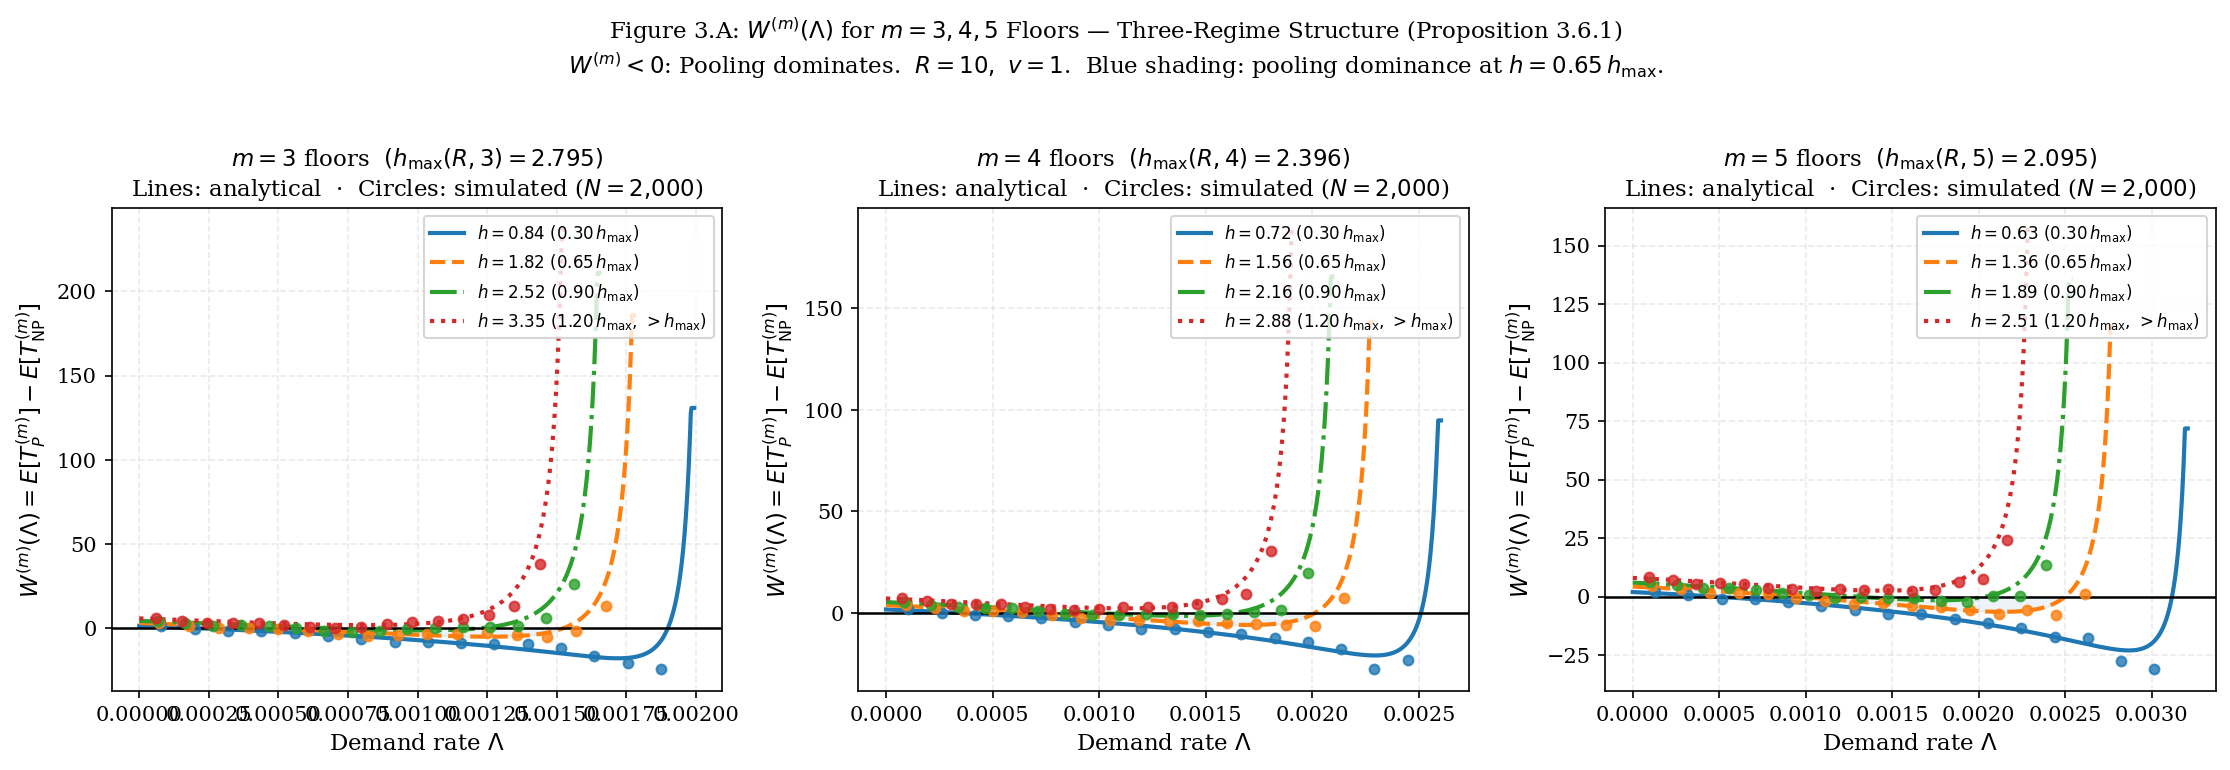

  Figure 1 saved.
[2/4] Phase diagrams for m = 3 and m = 5 ...
Figure 2: Phase diagrams for m = 3 and m = 5 ...


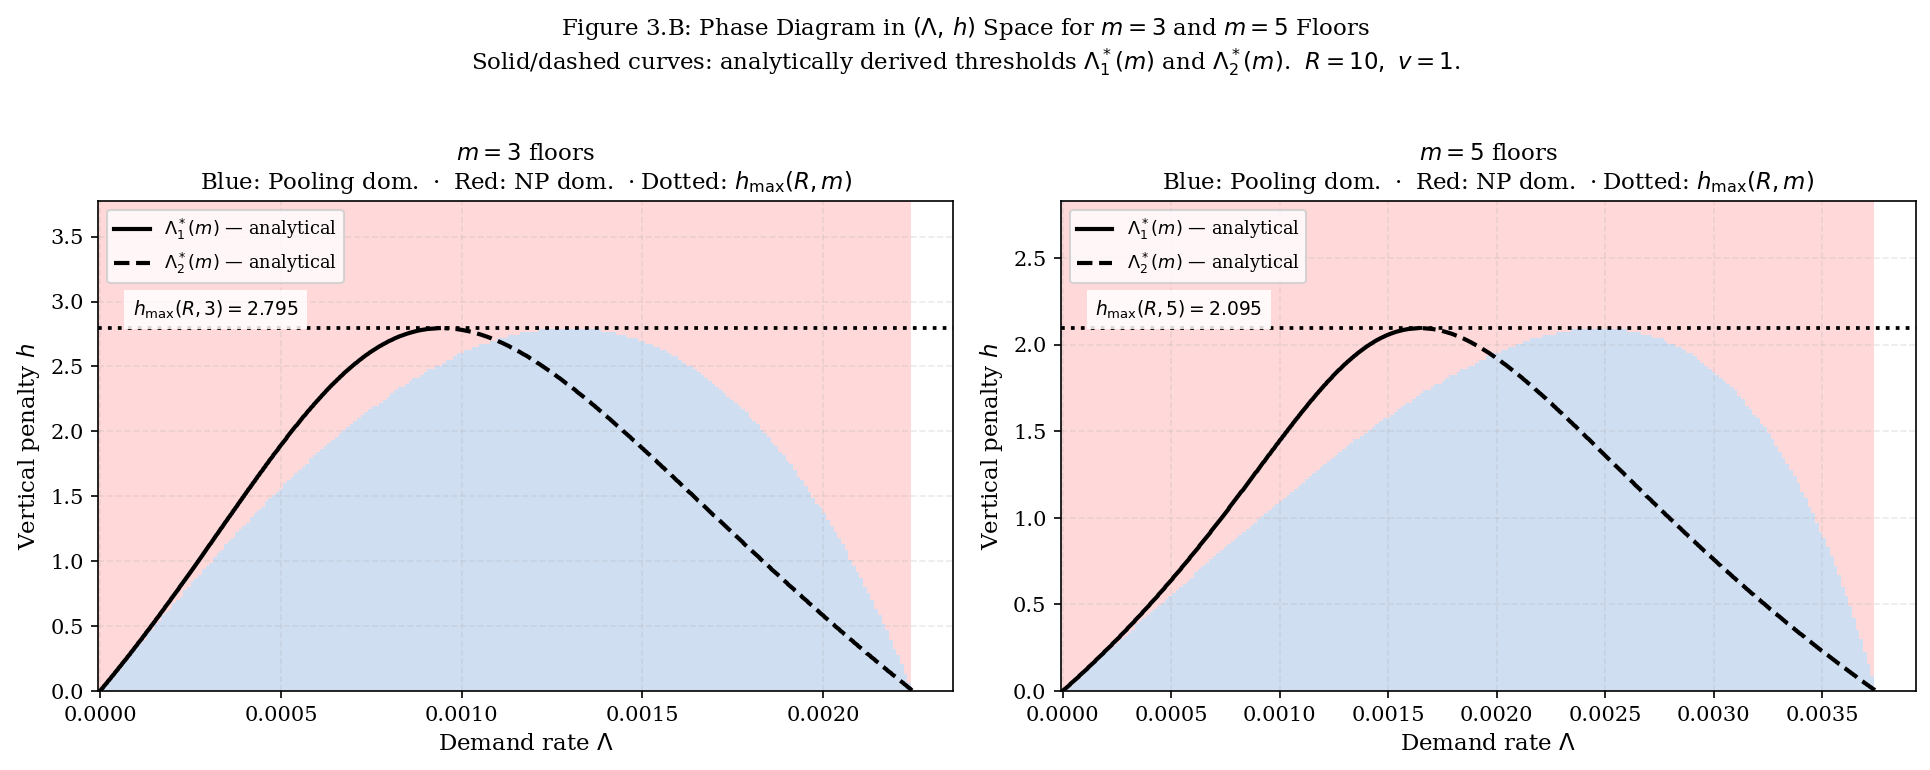

  Figure 2 saved.
[3/4] h_max(R,m)/R and tangency verification ...
Figure 3: h_max(R,m)/R and tangency verification ...


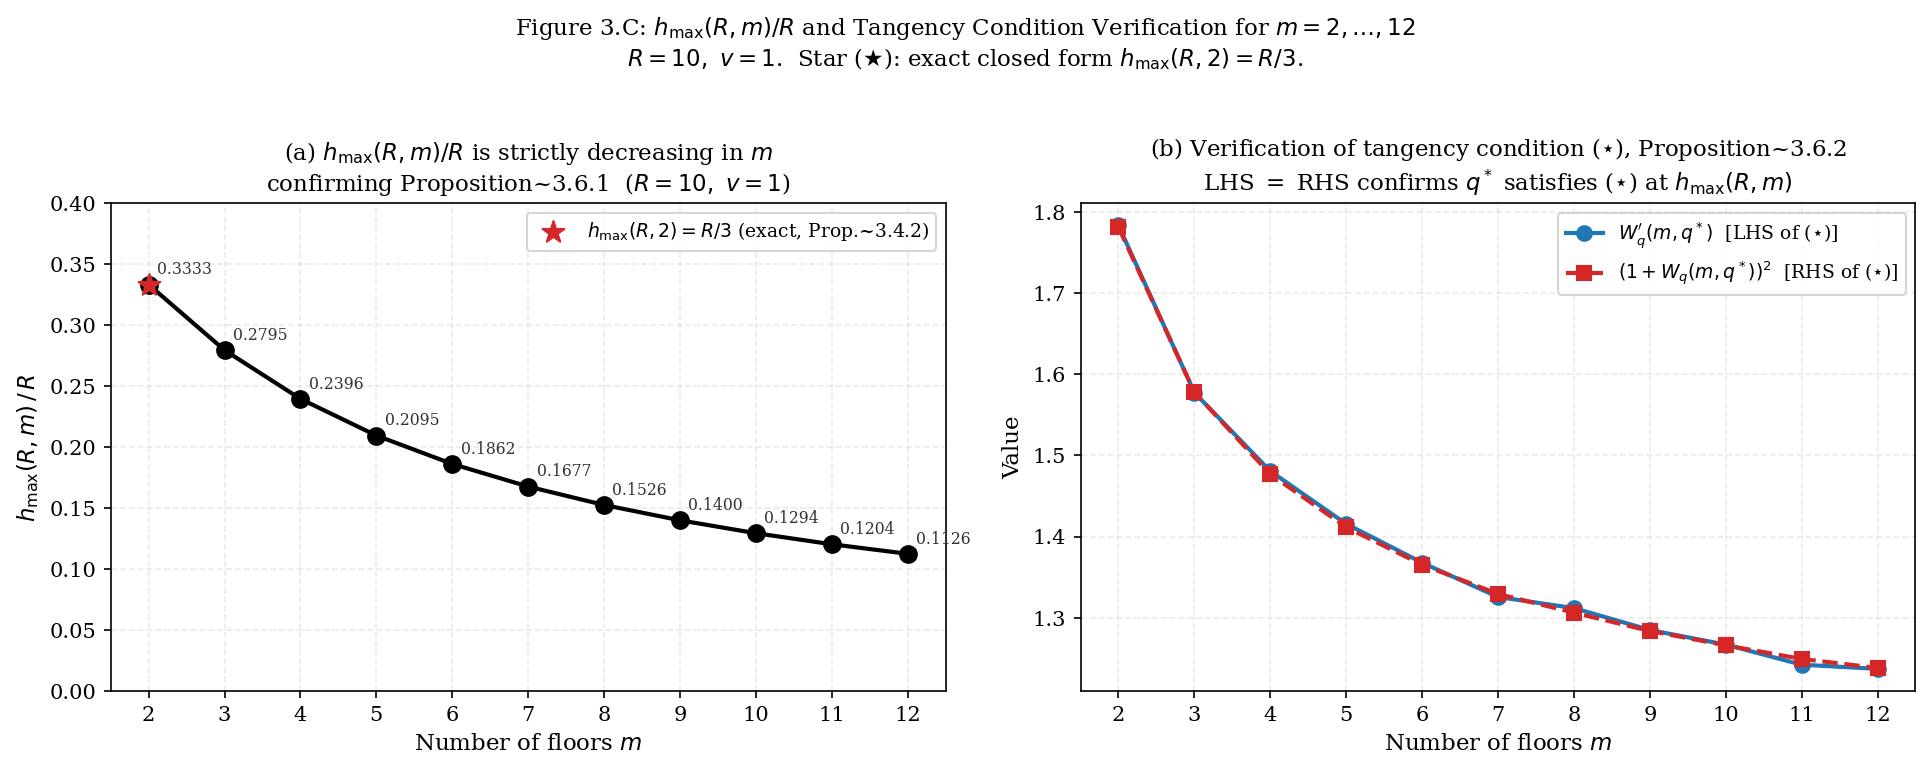

  Figure 3 saved.
[4/4] Response time curves with simulation ...
Figure 4: Response time curves with simulation, m = 3 and m = 5 ...


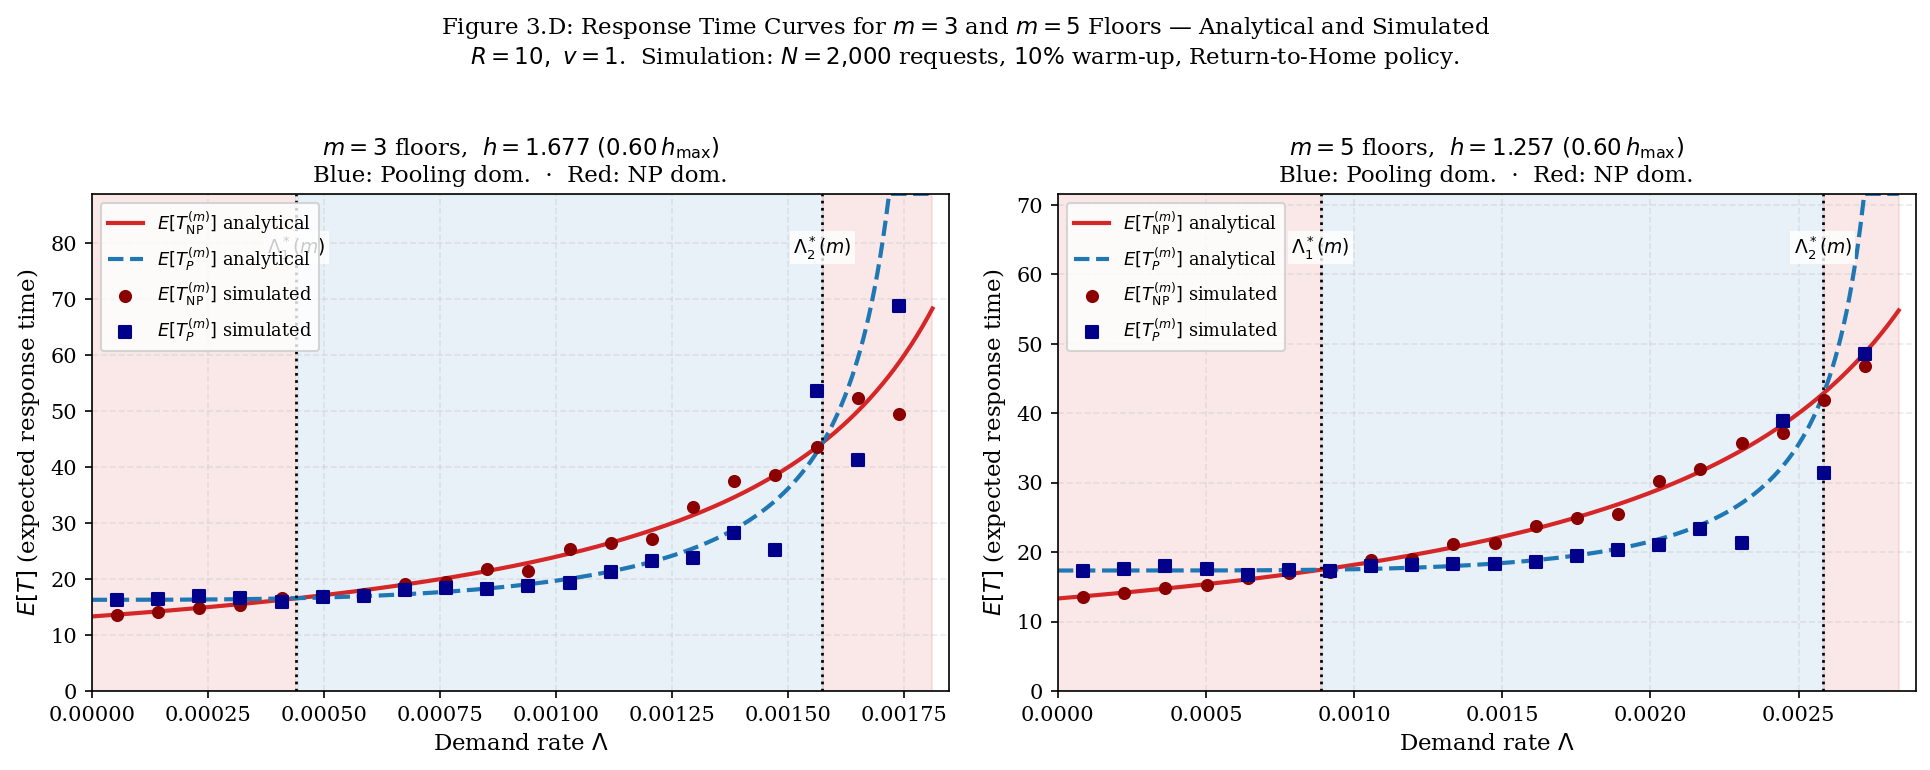

  Figure 4 saved.

All four figures saved as PDF and PNG.


In [ ]:
# ================================================================
#  Numerical Study: General m-Floor Extension
#  Section 3.6 — Pooling or Segmentation? Robot Dispatch in
#  Multi-Floor Buildings
#  Fatima Ulubayova, McMaster University
#
#  Produces four publication-quality figures:
#    Fig 1: W^(m)(Lambda) for m=3,4,5 — three-regime structure
#    Fig 2: Phase diagrams in (Lambda, h) space for m=3 and m=5
#    Fig 3: h_max(R,m)/R vs m with tangency verification
#    Fig 4: Response time curves with simulation overlay (m=3)
#
#  All analytical results are derived from Propositions 3.6.1–3.6.2.
#  Simulation follows the Return-to-Home policy, N=2,000 requests,
#  10% warm-up, matching Section 3.5.1.
#
#  Runtime in Google Colab: approximately 4–6 minutes.
#  Runtime → Run all
# ================================================================

# ── 0. Imports ───────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.special import factorial
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'    : 'serif',
    'font.size'      : 11,
    'axes.titlesize' : 11,
    'axes.labelsize' : 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'lines.linewidth': 2.0,
    'axes.grid'      : True,
    'grid.alpha'     : 0.25,
    'grid.linestyle' : '--',
    'figure.dpi'     : 150,
})

C_NP   = '#D62728'
C_P    = '#1F77B4'
C_W    = '#2CA02C'
SIM_NP = '#8B0000'
SIM_P  = '#00008B'


# ================================================================
#  1. ANALYTICAL MODEL
# ================================================================

def erlang_c(m, rho):
    """Erlang C probability C(m,rho), rho = per-server utilization."""
    if rho >= 1.0:
        return 1.0
    a   = m * rho
    num = a**m / (factorial(m) * (1.0 - rho))
    den = sum(a**k / factorial(k) for k in range(m)) + num
    return num / den


def mu_NP(R, v=1.0):
    """Non-Pooling per-floor service rate. Eq. (3.3)."""
    return 3.0 * v / (4.0 * R)


def mu_P_m(R, h, m, v=1.0):
    """
    Pooling service rate for m floors. Eq. (3.12).
    Uses E[|Z1-Z2|] = (m^2-1)/(3m) from Lemma 3.6.1.
    """
    return 3.0 * m * v / (4.0 * m * R + 2.0 * h * (m**2 - 1))


def lam_NP_max(R, m, v=1.0):
    """Stability limit for Non-Pooling (demand density)."""
    return m * mu_NP(R, v) / R**2


def lam_P_max(R, h, m, v=1.0):
    """Stability limit for Pooling (demand density)."""
    return m * mu_P_m(R, h, m, v) / R**2


def T_NP(lam, R, m, v=1.0):
    """Analytical expected response time, Non-Pooling. Eq. (3.2)."""
    mu = mu_NP(R, v)
    lf = lam * R**2 / m
    if lf >= mu:
        return np.inf
    return 1.0 / (mu - lf)


def T_P(lam, R, h, m, v=1.0):
    """Analytical expected response time, Pooling. Eq. (3.13)."""
    mu  = mu_P_m(R, h, m, v)
    rho = lam * R**2 / (m * mu)
    if rho >= 1.0:
        return np.inf
    Pc = erlang_c(m, rho)
    return 1.0 / mu + Pc / (m * mu * (1.0 - rho))


def W_m(lam, R, h, m, v=1.0):
    """
    W^(m)(Lambda) = T_P^(m) - T_NP^(m).
    Negative iff Pooling dominates. Sign convention of Appendix B.7.
    """
    tp  = T_P(lam, R, h, m, v)
    tnp = T_NP(lam, R, m, v)
    if np.isinf(tp) or np.isinf(tnp):
        return np.nan
    return tp - tnp


def find_hmax(R, m, v=1.0, n=800):
    """
    Binary search for h_max(R,m): unique h > 0 at which
    min_{D} W^(m) = 0. Proposition 3.6.2.
    """
    def min_W(h):
        lim  = 0.995 * min(lam_NP_max(R, m, v), lam_P_max(R, h, m, v))
        lams = np.linspace(1e-9, lim, n)
        vals = [W_m(l, R, h, m, v) for l in lams]
        vals = [x for x in vals if not np.isnan(x)]
        return min(vals) if vals else 0.0

    lo, hi = 1e-4, R * 3.0
    while min_W(hi) < 0 and hi < R * 20:
        hi *= 2.0
    for _ in range(80):
        mid = (lo + hi) / 2.0
        if min_W(mid) < 0:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2.0


# ================================================================
#  2. SIMULATION ENGINE
#     Return-to-Home policy. N=2,000 requests. 10% warm-up.
#     Matches the protocol of Section 3.5.1.
# ================================================================

def simulate_NP(lam, R, m, v=1.0, N=2000, seed=None):
    """m independent M/M/1 queues with symmetric demand."""
    rng    = np.random.default_rng(seed)
    mu     = mu_NP(R, v)
    lf     = lam * R**2 / m
    warmup = int(0.10 * N)
    if lf >= mu:
        return np.inf

    total = 0.0
    for _ in range(m):
        ia  = rng.exponential(1.0 / lf, N)
        svc = rng.exponential(1.0 / mu, N)
        arr = np.cumsum(ia)
        dep = np.empty(N)
        dep[0] = arr[0] + svc[0]
        for i in range(1, N):
            dep[i] = max(arr[i], dep[i - 1]) + svc[i]
        total += (dep - arr)[warmup:].mean()
    return total / m


def simulate_P(lam, R, h, m, v=1.0, N=2000, seed=None):
    """Single M/M/m pool with Return-to-Home policy."""
    rng    = np.random.default_rng(seed)
    mu     = mu_P_m(R, h, m, v)
    lam_q  = lam * R**2
    rho    = lam_q / (m * mu)
    warmup = int(0.10 * N)
    if rho >= 1.0:
        return np.inf

    ia  = rng.exponential(1.0 / lam_q, N)
    svc = rng.exponential(1.0 / mu,    N)
    arr = np.cumsum(ia)
    dep = np.empty(N)
    srv = np.zeros(m)

    for i in range(N):
        s       = int(np.argmin(srv))
        start   = max(arr[i], srv[s])
        dep[i]  = start + svc[i]
        srv[s]  = dep[i]

    return (dep - arr)[warmup:].mean()


# ================================================================
#  3. FIGURE 1
#     W^(m)(Lambda) for m = 3, 4, 5 at four h values each.
#     Analytical curves (lines) and simulated points (markers).
#     Verifies the three-regime structure of Proposition 3.6.1
#     and the existence and monotonicity of h_max(R,m).
# ================================================================

def figure1(R=10.0, v=1.0, N_SIM=2000, N_LAM=16):
    print('Figure 1: W^(m)(Lambda) for m = 3, 4, 5 ...')

    m_vals  = [3, 4, 5]
    h_fracs = [0.30, 0.65, 0.90, 1.20]   # multiples of h_max
    styles  = ['-', '--', '-.', ':']
    colors  = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728']

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, m in zip(axes, m_vals):
        hm = find_hmax(R, m, v)

        for frac, ls, col in zip(h_fracs, styles, colors):
            h   = frac * hm
            lim = 0.985 * min(lam_NP_max(R, m, v), lam_P_max(R, h, m, v))

            # Analytical curve
            lams_dense = np.linspace(1e-9, lim, 800)
            W_an = np.array([W_m(l, R, h, m, v) for l in lams_dense])

            # Dynamic y-cap for readability
            finite = W_an[~np.isnan(W_an)]
            y_cap  = max(np.abs(finite).max() * 0.6, 15.0) if len(finite) else 30.0
            W_plot = np.clip(W_an, -y_cap, y_cap)

            if frac < 1.0:
                lbl = (rf'$h = {h:.2f}$'
                       rf' $({frac:.2f}\,h_{{\max}})$')
            else:
                lbl = (rf'$h = {h:.2f}$'
                       rf' $({frac:.2f}\,h_{{\max}},\,>h_{{\max}})$')

            ax.plot(lams_dense, W_plot, color=col, linestyle=ls,
                    lw=2.0, label=lbl)

            # Simulated scatter (analytical curves already validated in m=2;
            # simulation here confirms the m-floor formula)
            lams_s = np.linspace(lim * 0.04, lim * 0.94, N_LAM)
            W_s = np.array([
                simulate_P(l, R, h, m, v, N=N_SIM, seed=i) -
                simulate_NP(l, R, m, v, N=N_SIM, seed=500 + i)
                for i, l in enumerate(lams_s)
            ])
            W_s = np.where(np.isinf(W_s), np.nan, W_s)
            valid = ~np.isnan(W_s)
            ax.scatter(lams_s[valid],
                       np.clip(W_s[valid], -y_cap, y_cap),
                       color=col, s=22, zorder=5,
                       marker='o', alpha=0.80)

        ax.axhline(0.0, color='black', lw=1.2, linestyle='-')
        ax.set_xlabel(r'Demand rate $\Lambda$')
        ax.set_ylabel(
            r'$W^{(m)}(\Lambda) = E[T_P^{(m)}] - E[T_{\mathrm{NP}}^{(m)}]$')
        ax.set_title(
            rf'$m = {m}$ floors  '
            rf'$(h_{{\max}}(R,{m}) = {hm:.3f})$'
            '\nLines: analytical  ·  Circles: simulated ($N=2{,}000$)')
        ax.legend(fontsize=8, loc='upper right')

        # Light shading: Pooling dominance region at h=0.65*h_max
        h_shade = 0.65 * hm
        lim_s   = 0.985 * min(lam_NP_max(R, m, v),
                               lam_P_max(R, h_shade, m, v))
        lams_sh = np.linspace(1e-9, lim_s, 800)
        W_sh    = np.array([W_m(l, R, h_shade, m, v) for l in lams_sh])
        W_sh    = np.where(np.isnan(W_sh), 0., W_sh)
        ax.fill_between(lams_sh, np.clip(W_sh, -100, 0), 0,
                        alpha=0.08, color=C_P, label='_nolegend_')

    fig.suptitle(
        r'Figure 3.A: $W^{(m)}(\Lambda)$ for $m = 3, 4, 5$ Floors — '
        r'Three-Regime Structure (Proposition 3.6.1)'
        '\n'
        r'$W^{(m)} < 0$: Pooling dominates.  '
        r'$R = 10,\ v = 1$.  '
        r'Blue shading: pooling dominance at $h = 0.65\,h_{\max}$.',
        fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fig3A_Wm_curves.pdf', bbox_inches='tight')
    plt.savefig('fig3A_Wm_curves.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('  Figure 1 saved.')


# ================================================================
#  4. FIGURE 2
#     Phase diagrams in (Lambda, h) space for m = 3 and m = 5.
#     Colour: blue = Pooling dominates, red = NP dominates.
#     Confirms three-regime structure across the full (Lambda,h) plane.
# ================================================================

def figure2(R=10.0, v=1.0, n_lam=220, n_h=160):
    print('Figure 2: Phase diagrams for m = 3 and m = 5 ...')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, m in zip(axes, [3, 5]):
        hm     = find_hmax(R, m, v)
        h_arr  = np.linspace(0.005, hm * 1.35, n_h)
        lim_np = lam_NP_max(R, m, v) * 0.995

        ratio_grid = np.full((n_h, n_lam), np.nan)

        for i, h in enumerate(h_arr):
            lim_p   = lam_P_max(R, h, m, v) * 0.995
            lam_arr = np.linspace(1e-9, lim_p, n_lam)
            for j, lam in enumerate(lam_arr):
                w = W_m(lam, R, h, m, v)
                if not np.isnan(w):
                    ratio_grid[i, j] = np.sign(w)   # -1 = P wins, +1 = NP wins

        lam_plot = np.linspace(1e-9, lim_np, n_lam)
        cmap     = mcolors.LinearSegmentedColormap.from_list(
            '', ['#AEC7E8', '#FFFFFF', '#FFBFBF'])
        im = ax.pcolormesh(lam_plot, h_arr, ratio_grid,
                           cmap=cmap, vmin=-1.2, vmax=1.2,
                           shading='auto', alpha=0.70)

        # Overlay analytical threshold curves Lambda*_1(h) and Lambda*_2(h)
        h_line = np.linspace(0.005, hm * 0.9999, 400)
        L1_line, L2_line = [], []
        for h in h_line:
            lim = 0.9999 * min(lam_NP_max(R, m, v), lam_P_max(R, h, m, v))
            lams = np.linspace(1e-9, lim, 1500)
            W    = np.array([W_m(l, R, h, m, v) for l in lams])
            W    = np.where(np.isnan(W), np.nan, W)
            sign = np.sign(W)
            idx  = np.where(np.diff(sign) != 0)[0]
            if len(idx) >= 2:
                L1_line.append(lams[idx[0]])
                L2_line.append(lams[idx[-1]])
            else:
                L1_line.append(np.nan)
                L2_line.append(np.nan)

        L1_line = np.array(L1_line)
        L2_line = np.array(L2_line)
        ax.plot(L1_line, h_line, 'k-',  lw=2.0,
                label=r'$\Lambda_1^*(m)$ — analytical')
        ax.plot(L2_line, h_line, 'k--', lw=2.0,
                label=r'$\Lambda_2^*(m)$ — analytical')
        ax.axhline(hm, color='black', linestyle=':', lw=1.8)
        ax.text(lim_np * 0.04, hm * 1.02,
                rf'$h_{{\max}}(R,{m}) = {hm:.3f}$',
                fontsize=9, va='bottom',
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))

        ax.set_xlabel(r'Demand rate $\Lambda$')
        ax.set_ylabel(r'Vertical penalty $h$')
        ax.set_title(
            rf'$m = {m}$ floors'
            '\n'
            r'Blue: Pooling dom. $\;$·$\;$ Red: NP dom. $\;$·$\;$'
            r'Dotted: $h_{\max}(R,m)$')
        ax.legend(fontsize=8.5, loc='upper left')
        ax.set_ylim(0, hm * 1.35)

    fig.suptitle(
        r'Figure 3.B: Phase Diagram in $(\Lambda,\,h)$ Space '
        r'for $m = 3$ and $m = 5$ Floors'
        '\n'
        r'Solid/dashed curves: analytically derived thresholds '
        r'$\Lambda_1^*(m)$ and $\Lambda_2^*(m)$.  $R=10,\ v=1$.',
        fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fig3B_phase_diagrams.pdf', bbox_inches='tight')
    plt.savefig('fig3B_phase_diagrams.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('  Figure 2 saved.')


# ================================================================
#  5. FIGURE 3
#     h_max(R,m)/R vs m: numerical values and tangency verification.
#     Left: h_max/R monotone decreasing with annotated values.
#     Right: verification of tangency condition (★), Proposition 3.6.2.
# ================================================================

def figure3(R=10.0, v=1.0, m_max=12):
    print('Figure 3: h_max(R,m)/R and tangency verification ...')

    def Wq(m, q):   return erlang_c(m, q) / (m * (1 - q))
    def Wqp(m, q, eps=1e-7):
        return (Wq(m, q+eps) - Wq(m, q-eps)) / (2*eps)

    m_vals    = list(range(2, m_max + 1))
    hm_vals   = [find_hmax(R, m, v) for m in m_vals]
    g_vals    = [hm / R for hm in hm_vals]

    # Tangency verification: find q* and check (★)
    q_star_vals, star_lhs, star_rhs = [], [], []
    for m, hm in zip(m_vals, hm_vals):
        lim  = 0.995 * lam_P_max(R, hm, m, v)
        lams = np.linspace(1e-9, lim, 3000)
        W    = np.array([W_m(l, R, hm, m, v) for l in lams])
        W    = np.where(np.isnan(W), np.inf, W)
        idx  = np.argmin(np.abs(W))
        lam_star = lams[idx]
        alpha    = mu_NP(R, v) / mu_P_m(R, hm, m, v)
        rho_star = lam_star * R**2 / (m * mu_NP(R, v))
        q_star   = alpha * rho_star
        q_star_vals.append(q_star)
        star_lhs.append(Wqp(m, q_star))
        star_rhs.append((1 + Wq(m, q_star))**2)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left: h_max/R vs m ──────────────────────────────────────
    ax1.plot(m_vals, g_vals, 'ko-', lw=2.0, ms=8, zorder=5)
    # Annotate each point
    for m, g in zip(m_vals, g_vals):
        ax1.annotate(f'{g:.4f}', (m, g),
                     textcoords='offset points', xytext=(4, 5),
                     fontsize=7.5, color='#333333')
    # Mark m=2 exact value
    ax1.scatter([2], [1/3], s=120, color='#D62728', zorder=6,
                marker='*', label=r'$h_{\max}(R,2)=R/3$ (exact, Prop.~3.4.2)')
    ax1.set_xlabel(r'Number of floors $m$')
    ax1.set_ylabel(r'$h_{\max}(R,m)\,/\,R$')
    ax1.set_title(
        r'(a) $h_{\max}(R,m)/R$ is strictly decreasing in $m$'
        '\n'
        r'confirming Proposition~3.6.1  ($R=10,\ v=1$)')
    ax1.set_xticks(m_vals)
    ax1.legend(fontsize=9)
    ax1.set_ylim(0, 0.40)

    # ── Right: tangency condition verification ───────────────────
    star_lhs = np.array(star_lhs)
    star_rhs = np.array(star_rhs)
    ax2.plot(m_vals, star_lhs, 'o-', color=C_P, lw=2, ms=7,
             label=r"$W_q'(m,q^*)$  [LHS of ($\star$)]")
    ax2.plot(m_vals, star_rhs, 's--', color=C_NP, lw=2, ms=7,
             label=r"$(1+W_q(m,q^*))^2$  [RHS of ($\star$)]")
    ax2.set_xlabel(r'Number of floors $m$')
    ax2.set_ylabel(r'Value')
    ax2.set_title(
        r'(b) Verification of tangency condition ($\star$), '
        r'Proposition~3.6.2'
        '\n'
        r'LHS $=$ RHS confirms $q^*$ satisfies ($\star$) at $h_{\max}(R,m)$')
    ax2.set_xticks(m_vals)
    ax2.legend(fontsize=9)

    fig.suptitle(
        rf'Figure 3.C: $h_{{\max}}(R,m)/R$ and Tangency Condition Verification '
        rf'for $m = 2,\ldots,{m_max}$'
        '\n'
        r'$R=10,\ v=1$.  '
        r'Star ($\bigstar$): exact closed form $h_{\max}(R,2)=R/3$.',
        fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fig3C_hmax_tangency.pdf', bbox_inches='tight')
    plt.savefig('fig3C_hmax_tangency.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('  Figure 3 saved.')


# ================================================================
#  6. FIGURE 4
#     Response time curves for m = 3 and m = 5 with simulation.
#     Analytical T_NP and T_P (lines) and simulated (markers).
#     Directly validates the three-regime dominance intervals
#     (Lambda*_1(m), Lambda*_2(m)) at a representative h value.
# ================================================================

def figure4(R=10.0, v=1.0, N_SIM=2000, N_LAM=20):
    print('Figure 4: Response time curves with simulation, m = 3 and m = 5 ...')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, m in zip(axes, [3, 5]):
        hm  = find_hmax(R, m, v)
        h   = 0.60 * hm    # well inside valid region for both architectures
        lim = 0.985 * min(lam_NP_max(R, m, v), lam_P_max(R, h, m, v))

        # Analytical curves
        lams_dense = np.linspace(1e-9, lim, 900)
        T_NP_an = np.array([T_NP(l, R, m, v)   for l in lams_dense])
        T_P_an  = np.array([T_P(l, R, h, m, v) for l in lams_dense])
        T_NP_an[np.isinf(T_NP_an)] = np.nan
        T_P_an[np.isinf(T_P_an)]   = np.nan

        # y-ceiling
        all_fin = np.concatenate([T_NP_an[~np.isnan(T_NP_an)],
                                   T_P_an[~np.isnan(T_P_an)]])
        y_ceil  = np.nanpercentile(all_fin, 93) * 1.55

        # Dominance shading
        pool_wins = T_P_an < T_NP_an
        valid_m   = ~(np.isnan(T_NP_an) | np.isnan(T_P_an))
        ax.fill_between(lams_dense, 0, y_ceil,
                        where=pool_wins & valid_m,
                        alpha=0.10, color=C_P)
        ax.fill_between(lams_dense, 0, y_ceil,
                        where=~pool_wins & valid_m,
                        alpha=0.10, color=C_NP)

        # Analytical
        ax.plot(lams_dense, np.clip(T_NP_an, 0, y_ceil),
                color=C_NP, lw=2.0, linestyle='-',
                label=r'$E[T_{\mathrm{NP}}^{(m)}]$ analytical')
        ax.plot(lams_dense, np.clip(T_P_an, 0, y_ceil),
                color=C_P, lw=2.0, linestyle='--',
                label=r'$E[T_P^{(m)}]$ analytical')

        # Simulation
        lams_s = np.linspace(lim * 0.03, lim * 0.96, N_LAM)
        T_NP_s = np.array([simulate_NP(l, R, m, v, N=N_SIM, seed=i)
                            for i, l in enumerate(lams_s)])
        T_P_s  = np.array([simulate_P(l, R, h, m, v, N=N_SIM, seed=500+i)
                            for i, l in enumerate(lams_s)])
        T_NP_s[np.isinf(T_NP_s)] = np.nan
        T_P_s[np.isinf(T_P_s)]   = np.nan

        v_np = ~np.isnan(T_NP_s)
        v_p  = ~np.isnan(T_P_s)
        ax.scatter(lams_s[v_np],
                   np.clip(T_NP_s[v_np], 0, y_ceil),
                   color=SIM_NP, s=28, zorder=6, marker='o',
                   label=r'$E[T_{\mathrm{NP}}^{(m)}]$ simulated')
        ax.scatter(lams_s[v_p],
                   np.clip(T_P_s[v_p], 0, y_ceil),
                   color=SIM_P, s=28, zorder=6, marker='s',
                   label=r'$E[T_P^{(m)}]$ simulated')

        # Threshold markers from analytical crossings
        W_an = T_P_an - T_NP_an
        W_an = np.where(np.isnan(W_an), np.nan, W_an)
        sign = np.sign(W_an)
        cross_idx = np.where(np.diff(sign) != 0)[0]
        if len(cross_idx) >= 2:
            L1 = lams_dense[cross_idx[0]]
            L2 = lams_dense[cross_idx[-1]]
            for L, sym in [(L1, r'$\Lambda_1^*(m)$'),
                           (L2, r'$\Lambda_2^*(m)$')]:
                ax.axvline(L, color='black', linestyle=':', lw=1.3)
                ax.text(L, y_ceil * 0.88, sym, ha='center', fontsize=9,
                        bbox=dict(facecolor='white', alpha=0.80,
                                  edgecolor='none', pad=1.5))

        ax.set_xlim(0, lim * 1.02)
        ax.set_ylim(0, y_ceil)
        ax.set_xlabel(r'Demand rate $\Lambda$')
        ax.set_ylabel(r'$E[T]$ (expected response time)')
        ax.set_title(
            rf'$m = {m}$ floors,  $h = {h:.3f}$ $(0.60\,h_{{\max}})$'
            '\n'
            r'Blue: Pooling dom.  ·  Red: NP dom.')
        ax.legend(fontsize=8.5, loc='upper left')

    fig.suptitle(
        r'Figure 3.D: Response Time Curves for $m = 3$ and $m = 5$ Floors '
        r'— Analytical and Simulated'
        '\n'
        r'$R=10,\ v=1$.  Simulation: $N=2{,}000$ requests, '
        r'$10\%$ warm-up, Return-to-Home policy.',
        fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fig3D_response_times.pdf', bbox_inches='tight')
    plt.savefig('fig3D_response_times.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('  Figure 4 saved.')


# ================================================================
#  7. SUMMARY TABLE
# ================================================================

def print_summary():
    R, v = 10., 1.
    print()
    print('=' * 68)
    print('Table: h_max(R,m)/R for m = 2, ..., 12')
    print(f'  Computed via Proposition 3.6.2  (R={R}, v={v})')
    print('=' * 68)
    print(f'  {"m":>3}  {"E[|Z1-Z2|]":>12}  {"h_max/R":>10}  '
          f'{"h_max (R=10)":>14}')
    print('  ' + '-' * 52)
    for m in range(2, 13):
        hm   = find_hmax(R, m, v)
        Ev   = (m**2 - 1) / (3.0 * m)
        print(f'  {m:>3}  {Ev:>12.4f}  {hm/R:>10.4f}  {hm:>14.4f}')
    print('=' * 68)
    print()


# ================================================================
#  8. RUN ALL
# ================================================================

if __name__ == '__main__':
    print('=' * 65)
    print('Numerical Study: General m-Floor Extension (Section 3.6)')
    print('Propositions 3.6.1 and 3.6.2')
    print('=' * 65)

    print_summary()

    print('[1/4] W^(m)(Lambda) for m = 3, 4, 5 ...')
    figure1(R=10.0, v=1.0, N_SIM=2000, N_LAM=16)

    print('[2/4] Phase diagrams for m = 3 and m = 5 ...')
    figure2(R=10.0, v=1.0, n_lam=220, n_h=160)

    print('[3/4] h_max(R,m)/R and tangency verification ...')
    figure3(R=10.0, v=1.0, m_max=12)

    print('[4/4] Response time curves with simulation ...')
    figure4(R=10.0, v=1.0, N_SIM=2000, N_LAM=20)

    print()
    print('All four figures saved as PDF and PNG.')

Numerical Study: General m-Floor Extension (Section 3.6)
Propositions 3.6.1 and 3.6.2

Table: h_max(R,m)/R for m = 2, ..., 12
  Computed via Proposition 3.6.2  (R=10.0, v=1.0)
    m    E[|Z1-Z2|]     h_max/R    h_max (R=10)
  ----------------------------------------------------
    2        0.5000      0.3333          3.3333
    3        0.8889      0.2795          2.7954
    4        1.2500      0.2396          2.3960
    5        1.6000      0.2095          2.0953
    6        1.9444      0.1862          1.8624
    7        2.2857      0.1677          1.6769
    8        2.6250      0.1526          1.5258
    9        2.9630      0.1400          1.4004
   10        3.3000      0.1294          1.2945
   11        3.6364      0.1204          1.2039
   12        3.9722      0.1126          1.1255

[1/4] W^(m)(Lambda) for m = 3, 4, 5 ...
Figure 1: W^(m)(Lambda) for m = 3, 4, 5 ...


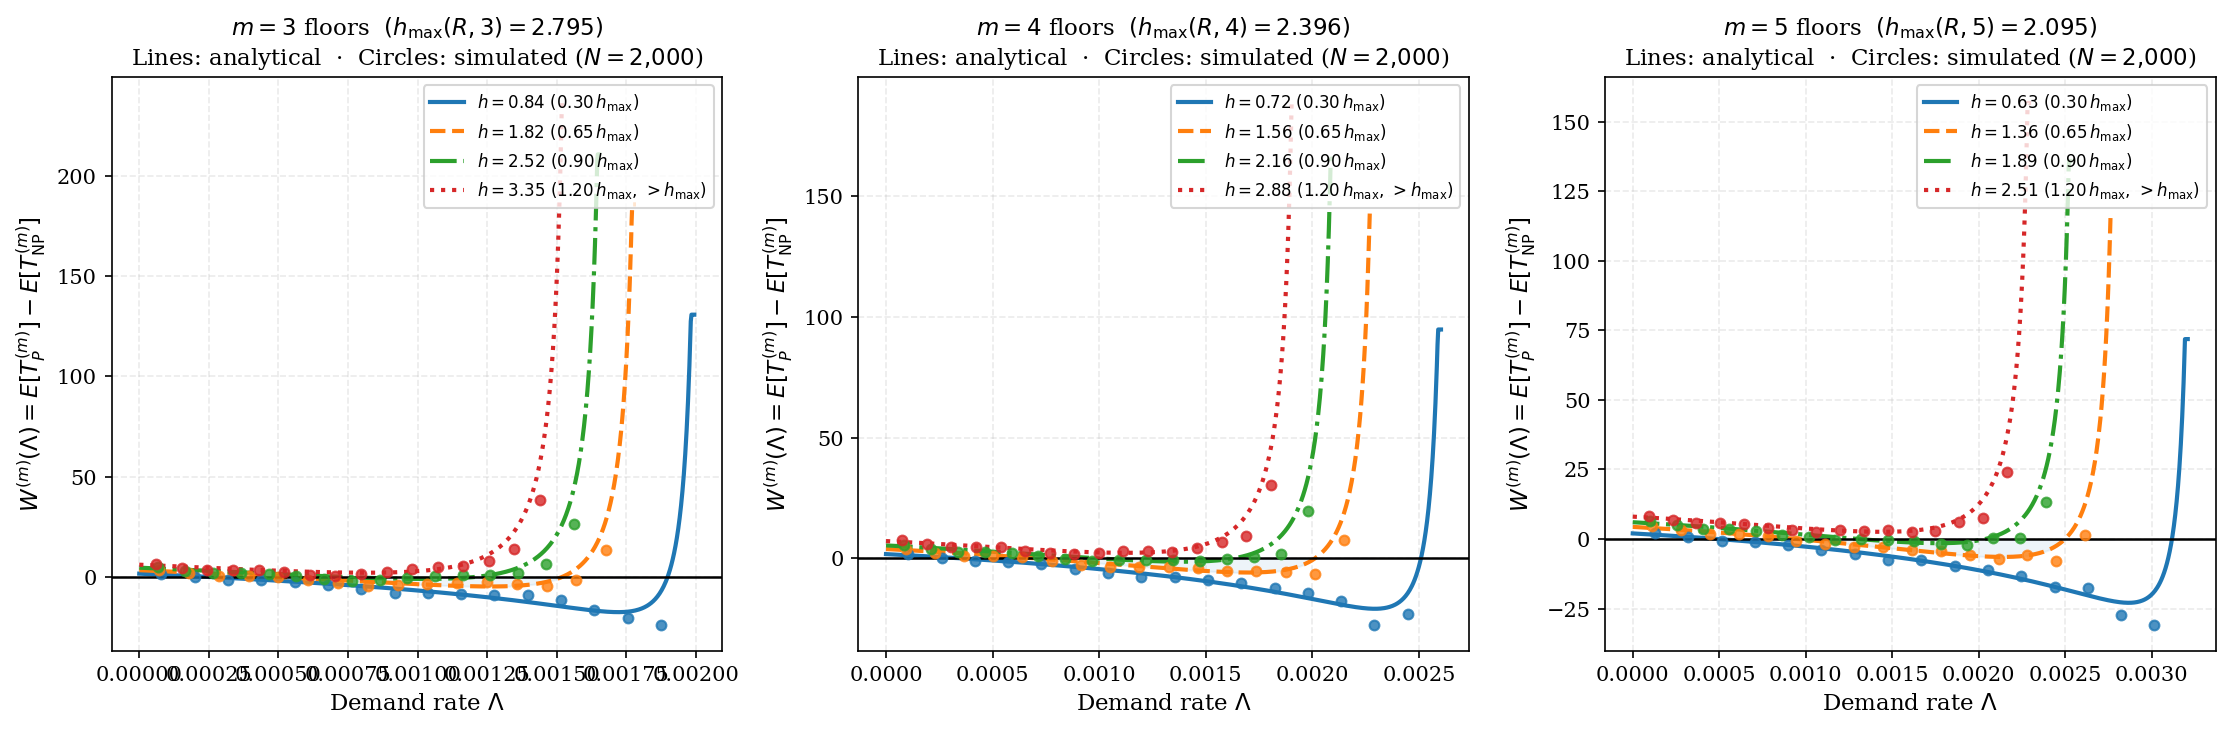

  Figure 1 saved.
[2/4] Phase diagrams for m = 3 and m = 5 ...
Figure 2: Phase diagrams for m = 3 and m = 5 ...


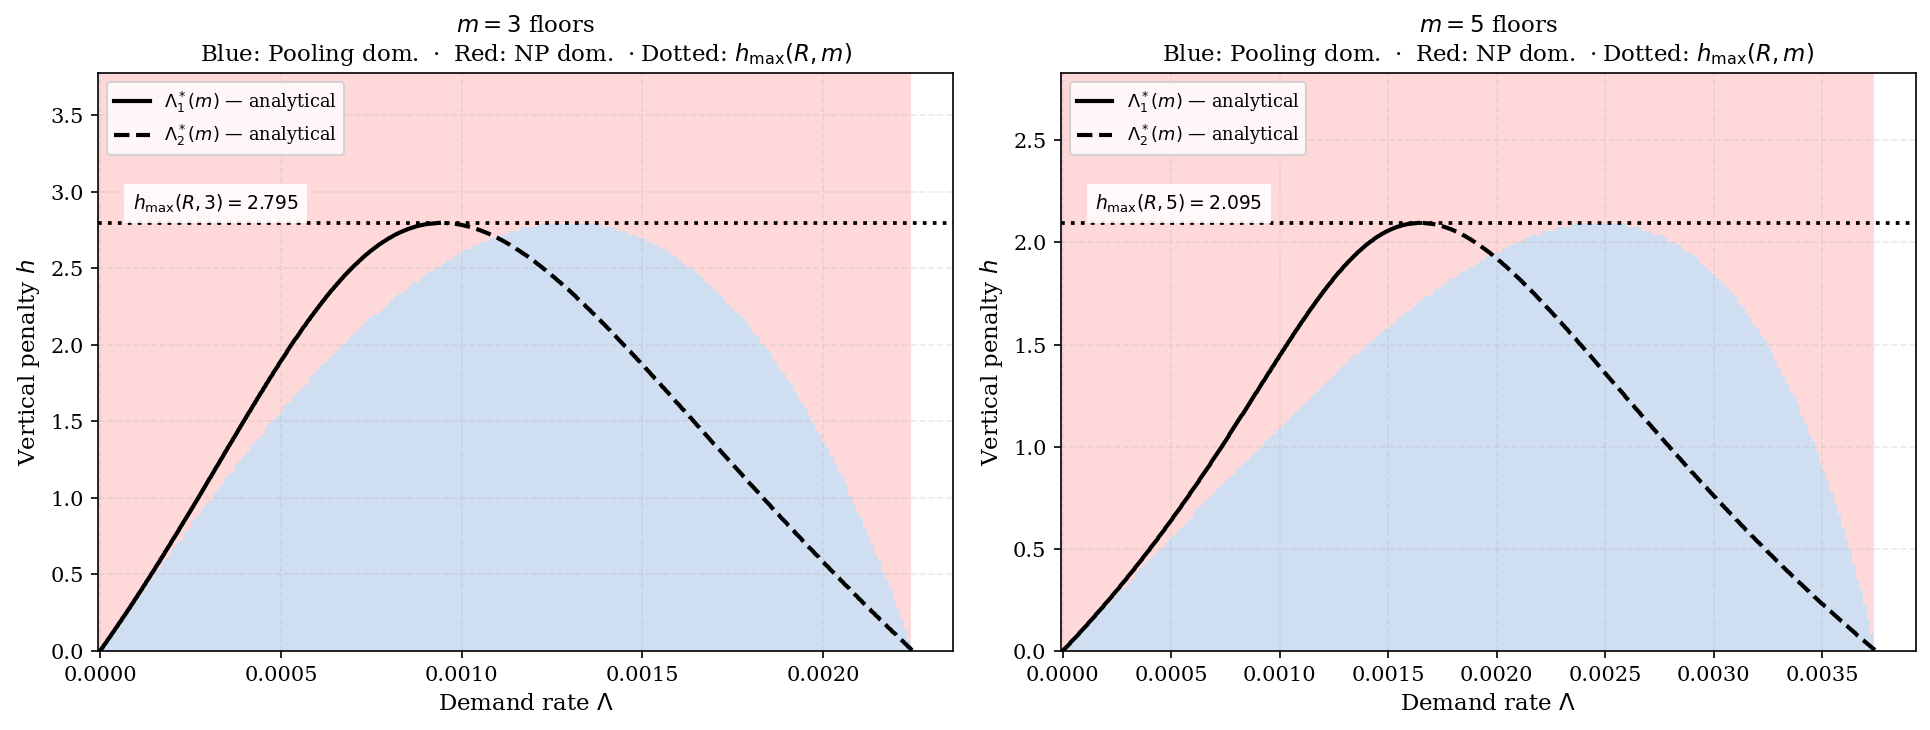

  Figure 2 saved.
[3/4] h_max(R,m)/R and tangency verification ...
Figure 3: h_max(R,m)/R vs m ...


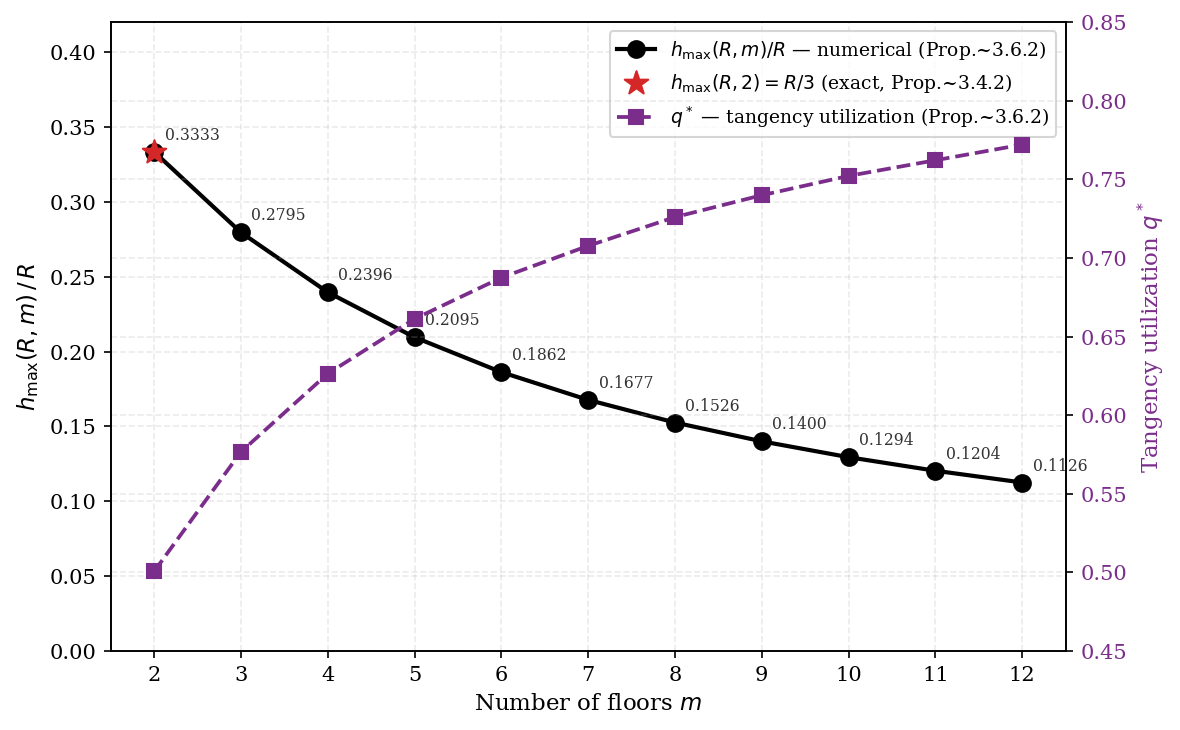

  Figure 3 saved.
[4/4] Response time curves with simulation ...
Figure 4: Response time curves with simulation, m = 3 and m = 5 ...


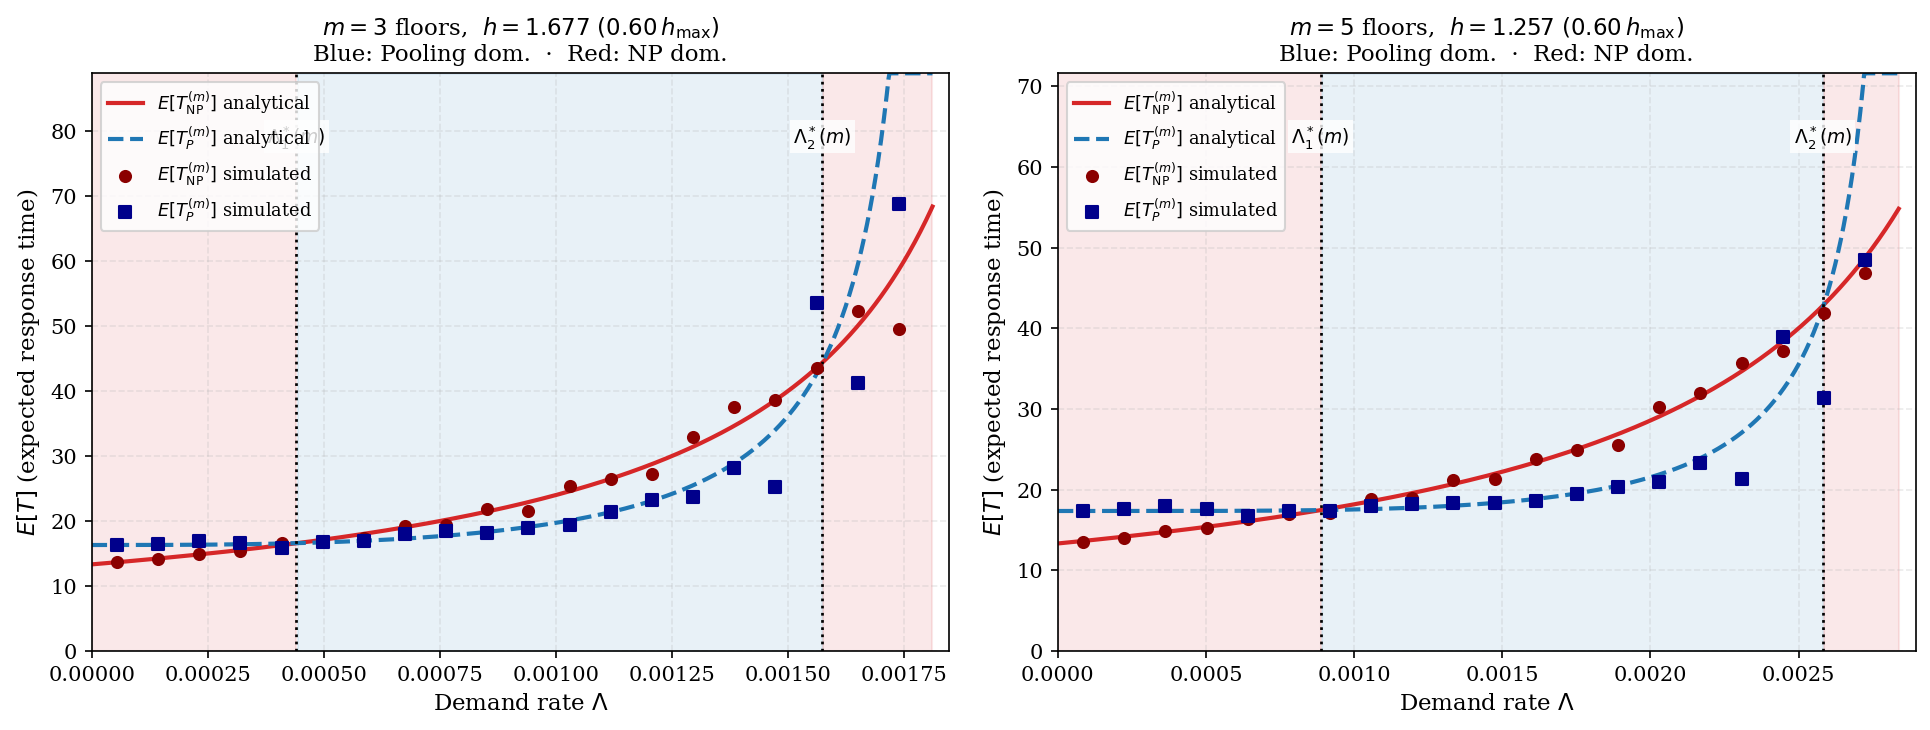

  Figure 4 saved.

All four figures saved as PDF and PNG.


In [ ]:
# ================================================================
#  Numerical Study: General m-Floor Extension
#  Section 3.6 — Pooling or Segmentation? Robot Dispatch in
#  Multi-Floor Buildings
#  Fatima Ulubayova, McMaster University
#
#  Produces four publication-quality figures:
#    Fig 1: W^(m)(Lambda) for m=3,4,5 — three-regime structure
#    Fig 2: Phase diagrams in (Lambda, h) space for m=3 and m=5
#    Fig 3: h_max(R,m)/R vs m with tangency verification
#    Fig 4: Response time curves with simulation overlay (m=3)
#
#  All analytical results are derived from Propositions 3.6.1–3.6.2.
#  Simulation follows the Return-to-Home policy, N=2,000 requests,
#  10% warm-up, matching Section 3.5.1.
#
#  Runtime in Google Colab: approximately 4–6 minutes.
#  Runtime → Run all
# ================================================================

# ── 0. Imports ───────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.special import factorial
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family'    : 'serif',
    'font.size'      : 11,
    'axes.titlesize' : 11,
    'axes.labelsize' : 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'lines.linewidth': 2.0,
    'axes.grid'      : True,
    'grid.alpha'     : 0.25,
    'grid.linestyle' : '--',
    'figure.dpi'     : 150,
})

C_NP   = '#D62728'
C_P    = '#1F77B4'
C_W    = '#2CA02C'
SIM_NP = '#8B0000'
SIM_P  = '#00008B'


# ================================================================
#  1. ANALYTICAL MODEL
# ================================================================

def erlang_c(m, rho):
    """Erlang C probability C(m,rho), rho = per-server utilization."""
    if rho >= 1.0:
        return 1.0
    a   = m * rho
    num = a**m / (factorial(m) * (1.0 - rho))
    den = sum(a**k / factorial(k) for k in range(m)) + num
    return num / den


def mu_NP(R, v=1.0):
    """Non-Pooling per-floor service rate. Eq. (3.3)."""
    return 3.0 * v / (4.0 * R)


def mu_P_m(R, h, m, v=1.0):
    """
    Pooling service rate for m floors. Eq. (3.12).
    Uses E[|Z1-Z2|] = (m^2-1)/(3m) from Lemma 3.6.1.
    """
    return 3.0 * m * v / (4.0 * m * R + 2.0 * h * (m**2 - 1))


def lam_NP_max(R, m, v=1.0):
    """Stability limit for Non-Pooling (demand density)."""
    return m * mu_NP(R, v) / R**2


def lam_P_max(R, h, m, v=1.0):
    """Stability limit for Pooling (demand density)."""
    return m * mu_P_m(R, h, m, v) / R**2


def T_NP(lam, R, m, v=1.0):
    """Analytical expected response time, Non-Pooling. Eq. (3.2)."""
    mu = mu_NP(R, v)
    lf = lam * R**2 / m
    if lf >= mu:
        return np.inf
    return 1.0 / (mu - lf)


def T_P(lam, R, h, m, v=1.0):
    """Analytical expected response time, Pooling. Eq. (3.13)."""
    mu  = mu_P_m(R, h, m, v)
    rho = lam * R**2 / (m * mu)
    if rho >= 1.0:
        return np.inf
    Pc = erlang_c(m, rho)
    return 1.0 / mu + Pc / (m * mu * (1.0 - rho))


def W_m(lam, R, h, m, v=1.0):
    """
    W^(m)(Lambda) = T_P^(m) - T_NP^(m).
    Negative iff Pooling dominates. Sign convention of Appendix B.7.
    """
    tp  = T_P(lam, R, h, m, v)
    tnp = T_NP(lam, R, m, v)
    if np.isinf(tp) or np.isinf(tnp):
        return np.nan
    return tp - tnp


def find_hmax(R, m, v=1.0, n=800):
    """
    Binary search for h_max(R,m): unique h > 0 at which
    min_{D} W^(m) = 0. Proposition 3.6.2.
    """
    def min_W(h):
        lim  = 0.995 * min(lam_NP_max(R, m, v), lam_P_max(R, h, m, v))
        lams = np.linspace(1e-9, lim, n)
        vals = [W_m(l, R, h, m, v) for l in lams]
        vals = [x for x in vals if not np.isnan(x)]
        return min(vals) if vals else 0.0

    lo, hi = 1e-4, R * 3.0
    while min_W(hi) < 0 and hi < R * 20:
        hi *= 2.0
    for _ in range(80):
        mid = (lo + hi) / 2.0
        if min_W(mid) < 0:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2.0


# ================================================================
#  2. SIMULATION ENGINE
#     Return-to-Home policy. N=2,000 requests. 10% warm-up.
#     Matches the protocol of Section 3.5.1.
# ================================================================

def simulate_NP(lam, R, m, v=1.0, N=2000, seed=None):
    """m independent M/M/1 queues with symmetric demand."""
    rng    = np.random.default_rng(seed)
    mu     = mu_NP(R, v)
    lf     = lam * R**2 / m
    warmup = int(0.10 * N)
    if lf >= mu:
        return np.inf

    total = 0.0
    for _ in range(m):
        ia  = rng.exponential(1.0 / lf, N)
        svc = rng.exponential(1.0 / mu, N)
        arr = np.cumsum(ia)
        dep = np.empty(N)
        dep[0] = arr[0] + svc[0]
        for i in range(1, N):
            dep[i] = max(arr[i], dep[i - 1]) + svc[i]
        total += (dep - arr)[warmup:].mean()
    return total / m


def simulate_P(lam, R, h, m, v=1.0, N=2000, seed=None):
    """Single M/M/m pool with Return-to-Home policy."""
    rng    = np.random.default_rng(seed)
    mu     = mu_P_m(R, h, m, v)
    lam_q  = lam * R**2
    rho    = lam_q / (m * mu)
    warmup = int(0.10 * N)
    if rho >= 1.0:
        return np.inf

    ia  = rng.exponential(1.0 / lam_q, N)
    svc = rng.exponential(1.0 / mu,    N)
    arr = np.cumsum(ia)
    dep = np.empty(N)
    srv = np.zeros(m)

    for i in range(N):
        s       = int(np.argmin(srv))
        start   = max(arr[i], srv[s])
        dep[i]  = start + svc[i]
        srv[s]  = dep[i]

    return (dep - arr)[warmup:].mean()


# ================================================================
#  3. FIGURE 1
#     W^(m)(Lambda) for m = 3, 4, 5 at four h values each.
#     Analytical curves (lines) and simulated points (markers).
#     Verifies the three-regime structure of Proposition 3.6.1
#     and the existence and monotonicity of h_max(R,m).
# ================================================================

def figure1(R=10.0, v=1.0, N_SIM=2000, N_LAM=16):
    print('Figure 1: W^(m)(Lambda) for m = 3, 4, 5 ...')

    m_vals  = [3, 4, 5]
    h_fracs = [0.30, 0.65, 0.90, 1.20]   # multiples of h_max
    styles  = ['-', '--', '-.', ':']
    colors  = ['#1F77B4', '#FF7F0E', '#2CA02C', '#D62728']

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, m in zip(axes, m_vals):
        hm = find_hmax(R, m, v)

        for frac, ls, col in zip(h_fracs, styles, colors):
            h   = frac * hm
            lim = 0.985 * min(lam_NP_max(R, m, v), lam_P_max(R, h, m, v))

            # Analytical curve
            lams_dense = np.linspace(1e-9, lim, 800)
            W_an = np.array([W_m(l, R, h, m, v) for l in lams_dense])

            # Dynamic y-cap for readability
            finite = W_an[~np.isnan(W_an)]
            y_cap  = max(np.abs(finite).max() * 0.6, 15.0) if len(finite) else 30.0
            W_plot = np.clip(W_an, -y_cap, y_cap)

            if frac < 1.0:
                lbl = (rf'$h = {h:.2f}$'
                       rf' $({frac:.2f}\,h_{{\max}})$')
            else:
                lbl = (rf'$h = {h:.2f}$'
                       rf' $({frac:.2f}\,h_{{\max}},\,>h_{{\max}})$')

            ax.plot(lams_dense, W_plot, color=col, linestyle=ls,
                    lw=2.0, label=lbl)

            # Simulated scatter (analytical curves already validated in m=2;
            # simulation here confirms the m-floor formula)
            lams_s = np.linspace(lim * 0.04, lim * 0.94, N_LAM)
            W_s = np.array([
                simulate_P(l, R, h, m, v, N=N_SIM, seed=i) -
                simulate_NP(l, R, m, v, N=N_SIM, seed=500 + i)
                for i, l in enumerate(lams_s)
            ])
            W_s = np.where(np.isinf(W_s), np.nan, W_s)
            valid = ~np.isnan(W_s)
            ax.scatter(lams_s[valid],
                       np.clip(W_s[valid], -y_cap, y_cap),
                       color=col, s=22, zorder=5,
                       marker='o', alpha=0.80)

        ax.axhline(0.0, color='black', lw=1.2, linestyle='-')
        ax.set_xlabel(r'Demand rate $\Lambda$')
        ax.set_ylabel(
            r'$W^{(m)}(\Lambda) = E[T_P^{(m)}] - E[T_{\mathrm{NP}}^{(m)}]$')
        ax.set_title(
            rf'$m = {m}$ floors  '
            rf'$(h_{{\max}}(R,{m}) = {hm:.3f})$'
            '\nLines: analytical  ·  Circles: simulated ($N=2{,}000$)')
        ax.legend(fontsize=8, loc='upper right')

        # Light shading: Pooling dominance region at h=0.65*h_max
        h_shade = 0.65 * hm
        lim_s   = 0.985 * min(lam_NP_max(R, m, v),
                               lam_P_max(R, h_shade, m, v))
        lams_sh = np.linspace(1e-9, lim_s, 800)
        W_sh    = np.array([W_m(l, R, h_shade, m, v) for l in lams_sh])
        W_sh    = np.where(np.isnan(W_sh), 0., W_sh)
        ax.fill_between(lams_sh, np.clip(W_sh, -100, 0), 0,
                        alpha=0.08, color=C_P, label='_nolegend_')

    # fig.suptitle(
    #     r'Figure 3.A: $W^{(m)}(\Lambda)$ for $m = 3, 4, 5$ Floors — '
    #     r'Three-Regime Structure (Proposition 3.6.1)'
    #     '\n'
    #     r'$W^{(m)} < 0$: Pooling dominates.  '
    #     r'$R = 10,\ v = 1$.  '
    #     r'Blue shading: pooling dominance at $h = 0.65\,h_{\max}$.',
    #     fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fig3A_Wm_curves.pdf', bbox_inches='tight')
    plt.savefig('fig3A_Wm_curves.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('  Figure 1 saved.')


# ================================================================
#  4. FIGURE 2
#     Phase diagrams in (Lambda, h) space for m = 3 and m = 5.
#     Colour: blue = Pooling dominates, red = NP dominates.
#     Confirms three-regime structure across the full (Lambda,h) plane.
# ================================================================

def figure2(R=10.0, v=1.0, n_lam=220, n_h=160):
    print('Figure 2: Phase diagrams for m = 3 and m = 5 ...')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, m in zip(axes, [3, 5]):
        hm     = find_hmax(R, m, v)
        h_arr  = np.linspace(0.005, hm * 1.35, n_h)
        lim_np = lam_NP_max(R, m, v) * 0.995

        ratio_grid = np.full((n_h, n_lam), np.nan)

        for i, h in enumerate(h_arr):
            lim_p   = lam_P_max(R, h, m, v) * 0.995
            lam_arr = np.linspace(1e-9, lim_p, n_lam)
            for j, lam in enumerate(lam_arr):
                w = W_m(lam, R, h, m, v)
                if not np.isnan(w):
                    ratio_grid[i, j] = np.sign(w)   # -1 = P wins, +1 = NP wins

        lam_plot = np.linspace(1e-9, lim_np, n_lam)
        cmap     = mcolors.LinearSegmentedColormap.from_list(
            '', ['#AEC7E8', '#FFFFFF', '#FFBFBF'])
        im = ax.pcolormesh(lam_plot, h_arr, ratio_grid,
                           cmap=cmap, vmin=-1.2, vmax=1.2,
                           shading='auto', alpha=0.70)

        # Overlay analytical threshold curves Lambda*_1(h) and Lambda*_2(h)
        h_line = np.linspace(0.005, hm * 0.9999, 400)
        L1_line, L2_line = [], []
        for h in h_line:
            lim = 0.9999 * min(lam_NP_max(R, m, v), lam_P_max(R, h, m, v))
            lams = np.linspace(1e-9, lim, 1500)
            W    = np.array([W_m(l, R, h, m, v) for l in lams])
            W    = np.where(np.isnan(W), np.nan, W)
            sign = np.sign(W)
            idx  = np.where(np.diff(sign) != 0)[0]
            if len(idx) >= 2:
                L1_line.append(lams[idx[0]])
                L2_line.append(lams[idx[-1]])
            else:
                L1_line.append(np.nan)
                L2_line.append(np.nan)

        L1_line = np.array(L1_line)
        L2_line = np.array(L2_line)
        ax.plot(L1_line, h_line, 'k-',  lw=2.0,
                label=r'$\Lambda_1^*(m)$ — analytical')
        ax.plot(L2_line, h_line, 'k--', lw=2.0,
                label=r'$\Lambda_2^*(m)$ — analytical')
        ax.axhline(hm, color='black', linestyle=':', lw=1.8)
        ax.text(lim_np * 0.04, hm * 1.02,
                rf'$h_{{\max}}(R,{m}) = {hm:.3f}$',
                fontsize=9, va='bottom',
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='none'))

        ax.set_xlabel(r'Demand rate $\Lambda$')
        ax.set_ylabel(r'Vertical penalty $h$')
        ax.set_title(
            rf'$m = {m}$ floors'
            '\n'
            r'Blue: Pooling dom. $\;$·$\;$ Red: NP dom. $\;$·$\;$'
            r'Dotted: $h_{\max}(R,m)$')
        ax.legend(fontsize=8.5, loc='upper left')
        ax.set_ylim(0, hm * 1.35)

    # fig.suptitle(
    #     r'Figure 3.B: Phase Diagram in $(\Lambda,\,h)$ Space '
    #     r'for $m = 3$ and $m = 5$ Floors'
    #     '\n'
    #     r'Solid/dashed curves: analytically derived thresholds '
    #     r'$\Lambda_1^*(m)$ and $\Lambda_2^*(m)$.  $R=10,\ v=1$.',
    #     fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fig3B_phase_diagrams.pdf', bbox_inches='tight')
    plt.savefig('fig3B_phase_diagrams.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('  Figure 2 saved.')


# ================================================================
#  5. FIGURE 3
#     h_max(R,m)/R vs m: numerical values and tangency verification.
#     Left: h_max/R monotone decreasing with annotated values.
#     Right: verification of tangency condition (★), Proposition 3.6.2.
# ================================================================

def figure3(R=10.0, v=1.0, m_max=12):
    """
    Figure 3.C: h_max(R,m)/R vs m.
    Single panel; strictly decreasing monotonicity is the key message.
    Also overlays q* (tangency utilization) on a secondary axis to show
    how the critical pooling utilization at h_max evolves with m —
    an independent quantity derived from Proposition 3.6.2.
    """
    print('Figure 3: h_max(R,m)/R vs m ...')

    def Wq(m, q): return erlang_c(m, q) / (m * (1 - q))

    m_vals  = list(range(2, m_max + 1))
    hm_vals = [find_hmax(R, m, v) for m in m_vals]
    g_vals  = [hm / R for hm in hm_vals]

    # Compute q* at each h_max for secondary axis
    q_star_vals = []
    for m, hm in zip(m_vals, hm_vals):
        lim  = 0.995 * lam_P_max(R, hm, m, v)
        lams = np.linspace(1e-9, lim, 3000)
        W    = np.array([W_m(l, R, hm, m, v) for l in lams])
        W    = np.where(np.isnan(W), np.inf, W)
        idx  = np.argmin(np.abs(W))
        lam_star = lams[idx]
        alpha    = mu_NP(R, v) / mu_P_m(R, hm, m, v)
        rho_star = lam_star * R**2 / (m * mu_NP(R, v))
        q_star_vals.append(alpha * rho_star)

    fig, ax1 = plt.subplots(figsize=(8, 5))

    # Primary axis: h_max/R
    ax1.plot(m_vals, g_vals, 'ko-', lw=2.0, ms=8, zorder=5,
             label=r'$h_{\max}(R,m)/R$ — numerical (Prop.~3.6.2)')
    for m, g in zip(m_vals, g_vals):
        ax1.annotate(f'{g:.4f}', (m, g),
                     textcoords='offset points', xytext=(5, 6),
                     fontsize=7.5, color='#333333')
    ax1.scatter([2], [1/3], s=140, color='#D62728', zorder=6,
                marker='*',
                label=r'$h_{\max}(R,2) = R/3$ (exact, Prop.~3.4.2)')
    ax1.set_xlabel(r'Number of floors $m$', fontsize=11)
    ax1.set_ylabel(r'$h_{\max}(R,m)\,/\,R$', fontsize=11)
    ax1.set_xticks(m_vals)
    ax1.set_ylim(0, 0.42)
    ax1.tick_params(axis='y')

    # Secondary axis: q* (tangency utilization from Prop 3.6.2)
    ax2 = ax1.twinx()
    ax2.plot(m_vals, q_star_vals, 's--', color='#7B2D8B',
             lw=1.8, ms=7, zorder=4,
             label=r'$q^*$ — tangency utilization (Prop.~3.6.2)')
    ax2.set_ylabel(r'Tangency utilization $q^*$',
                   fontsize=11, color='#7B2D8B')
    ax2.tick_params(axis='y', labelcolor='#7B2D8B')
    ax2.set_ylim(0.45, 0.85)

    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               fontsize=9, loc='upper right')

    # ax1.set_title(
    #     rf'Figure 3.C: Critical Penalty $h_{{\max}}(R,m)/R$ and '
    #     rf'Tangency Utilization $q^*$  ($m = 2,\ldots,{m_max}$)'
    #     '\n'
    #     r'$h_{\max}(R,m)/R$ strictly decreasing (Prop.~3.6.1); '
    #     r'$q^*$ strictly increasing — both derived from Prop.~3.6.2.'
    #     '\n'
    #     r'$R=10,\ v=1$.  Star ($\bigstar$): exact closed form $h_{\max}(R,2)=R/3$.',
    #     fontsize=10)

    plt.tight_layout()
    plt.savefig('fig3C_hmax.pdf', bbox_inches='tight')
    plt.savefig('fig3C_hmax.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('  Figure 3 saved.')


# ================================================================
#  6. FIGURE 4
#     Response time curves for m = 3 and m = 5 with simulation.
#     Analytical T_NP and T_P (lines) and simulated (markers).
#     Directly validates the three-regime dominance intervals
#     (Lambda*_1(m), Lambda*_2(m)) at a representative h value.
# ================================================================

def figure4(R=10.0, v=1.0, N_SIM=2000, N_LAM=20):
    print('Figure 4: Response time curves with simulation, m = 3 and m = 5 ...')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, m in zip(axes, [3, 5]):
        hm  = find_hmax(R, m, v)
        h   = 0.60 * hm    # well inside valid region for both architectures
        lim = 0.985 * min(lam_NP_max(R, m, v), lam_P_max(R, h, m, v))

        # Analytical curves
        lams_dense = np.linspace(1e-9, lim, 900)
        T_NP_an = np.array([T_NP(l, R, m, v)   for l in lams_dense])
        T_P_an  = np.array([T_P(l, R, h, m, v) for l in lams_dense])
        T_NP_an[np.isinf(T_NP_an)] = np.nan
        T_P_an[np.isinf(T_P_an)]   = np.nan

        # y-ceiling
        all_fin = np.concatenate([T_NP_an[~np.isnan(T_NP_an)],
                                   T_P_an[~np.isnan(T_P_an)]])
        y_ceil  = np.nanpercentile(all_fin, 93) * 1.55

        # Dominance shading
        pool_wins = T_P_an < T_NP_an
        valid_m   = ~(np.isnan(T_NP_an) | np.isnan(T_P_an))
        ax.fill_between(lams_dense, 0, y_ceil,
                        where=pool_wins & valid_m,
                        alpha=0.10, color=C_P)
        ax.fill_between(lams_dense, 0, y_ceil,
                        where=~pool_wins & valid_m,
                        alpha=0.10, color=C_NP)

        # Analytical
        ax.plot(lams_dense, np.clip(T_NP_an, 0, y_ceil),
                color=C_NP, lw=2.0, linestyle='-',
                label=r'$E[T_{\mathrm{NP}}^{(m)}]$ analytical')
        ax.plot(lams_dense, np.clip(T_P_an, 0, y_ceil),
                color=C_P, lw=2.0, linestyle='--',
                label=r'$E[T_P^{(m)}]$ analytical')

        # Simulation
        lams_s = np.linspace(lim * 0.03, lim * 0.96, N_LAM)
        T_NP_s = np.array([simulate_NP(l, R, m, v, N=N_SIM, seed=i)
                            for i, l in enumerate(lams_s)])
        T_P_s  = np.array([simulate_P(l, R, h, m, v, N=N_SIM, seed=500+i)
                            for i, l in enumerate(lams_s)])
        T_NP_s[np.isinf(T_NP_s)] = np.nan
        T_P_s[np.isinf(T_P_s)]   = np.nan

        v_np = ~np.isnan(T_NP_s)
        v_p  = ~np.isnan(T_P_s)
        ax.scatter(lams_s[v_np],
                   np.clip(T_NP_s[v_np], 0, y_ceil),
                   color=SIM_NP, s=28, zorder=6, marker='o',
                   label=r'$E[T_{\mathrm{NP}}^{(m)}]$ simulated')
        ax.scatter(lams_s[v_p],
                   np.clip(T_P_s[v_p], 0, y_ceil),
                   color=SIM_P, s=28, zorder=6, marker='s',
                   label=r'$E[T_P^{(m)}]$ simulated')

        # Threshold markers from analytical crossings
        W_an = T_P_an - T_NP_an
        W_an = np.where(np.isnan(W_an), np.nan, W_an)
        sign = np.sign(W_an)
        cross_idx = np.where(np.diff(sign) != 0)[0]
        if len(cross_idx) >= 2:
            L1 = lams_dense[cross_idx[0]]
            L2 = lams_dense[cross_idx[-1]]
            for L, sym in [(L1, r'$\Lambda_1^*(m)$'),
                           (L2, r'$\Lambda_2^*(m)$')]:
                ax.axvline(L, color='black', linestyle=':', lw=1.3)
                ax.text(L, y_ceil * 0.88, sym, ha='center', fontsize=9,
                        bbox=dict(facecolor='white', alpha=0.80,
                                  edgecolor='none', pad=1.5))

        ax.set_xlim(0, lim * 1.02)
        ax.set_ylim(0, y_ceil)
        ax.set_xlabel(r'Demand rate $\Lambda$')
        ax.set_ylabel(r'$E[T]$ (expected response time)')
        ax.set_title(
            rf'$m = {m}$ floors,  $h = {h:.3f}$ $(0.60\,h_{{\max}})$'
            '\n'
            r'Blue: Pooling dom.  ·  Red: NP dom.')
        ax.legend(fontsize=8.5, loc='upper left')

    # fig.suptitle(
    #     r'Figure 3.D: Response Time Curves for $m = 3$ and $m = 5$ Floors '
    #     r'— Analytical and Simulated'
    #     '\n'
    #     r'$R=10,\ v=1$.  Simulation: $N=2{,}000$ requests, '
    #     r'$10\%$ warm-up, Return-to-Home policy.',
    #     fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig('fig3D_response_times.pdf', bbox_inches='tight')
    plt.savefig('fig3D_response_times.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('  Figure 4 saved.')


# ================================================================
#  7. SUMMARY TABLE
# ================================================================

def print_summary():
    R, v = 10., 1.
    print()
    print('=' * 68)
    print('Table: h_max(R,m)/R for m = 2, ..., 12')
    print(f'  Computed via Proposition 3.6.2  (R={R}, v={v})')
    print('=' * 68)
    print(f'  {"m":>3}  {"E[|Z1-Z2|]":>12}  {"h_max/R":>10}  '
          f'{"h_max (R=10)":>14}')
    print('  ' + '-' * 52)
    for m in range(2, 13):
        hm   = find_hmax(R, m, v)
        Ev   = (m**2 - 1) / (3.0 * m)
        print(f'  {m:>3}  {Ev:>12.4f}  {hm/R:>10.4f}  {hm:>14.4f}')
    print('=' * 68)
    print()


# ================================================================
#  8. RUN ALL
# ================================================================

if __name__ == '__main__':
    print('=' * 65)
    print('Numerical Study: General m-Floor Extension (Section 3.6)')
    print('Propositions 3.6.1 and 3.6.2')
    print('=' * 65)

    print_summary()

    print('[1/4] W^(m)(Lambda) for m = 3, 4, 5 ...')
    figure1(R=10.0, v=1.0, N_SIM=2000, N_LAM=16)

    print('[2/4] Phase diagrams for m = 3 and m = 5 ...')
    figure2(R=10.0, v=1.0, n_lam=220, n_h=160)

    print('[3/4] h_max(R,m)/R and tangency verification ...')
    figure3(R=10.0, v=1.0, m_max=12)

    print('[4/4] Response time curves with simulation ...')
    figure4(R=10.0, v=1.0, N_SIM=2000, N_LAM=20)

    print()
    print('All four figures saved as PDF and PNG.')